In [34]:
import os
import json
import gc
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pyarrow.parquet as pq
    HAS_PYARROW = True
except Exception:
    HAS_PYARROW = False

from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.6f}".format)

RANDOM_STATE = 42
PLOT_DPI = 120
MAX_PLOT_SAMPLE = 2_000_000

print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("PyArrow available:", HAS_PYARROW)

Python: 3.12.12
Pandas: 2.3.3
NumPy: 2.0.2
PyArrow available: True


In [35]:
def detect_environment() -> str:
    if Path("/kaggle/input").exists() or "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
        return "kaggle"
    if "COLAB_RELEASE_TAG" in os.environ or "COLAB_GPU" in os.environ:
        return "colab"
    try:
        import google.colab  # noqa
        return "colab"
    except ImportError:
        return "local"


ENVIRONMENT = detect_environment()
IN_COLAB = ENVIRONMENT == "colab"
IN_KAGGLE = ENVIRONMENT == "kaggle"

if IN_COLAB:
    from google.colab import drive
    drive_root = Path("/content/drive/MyDrive")
    if not drive_root.exists():
        drive.mount("/content/drive")
    else:
        print("Google Drive already mounted.")

print("Detected environment:", ENVIRONMENT)

Detected environment: kaggle


In [36]:
PROJECT_NAME = "hm-recommender"

REQUIRED_PROCESSED_FILES = [
    "articles_processed.parquet",
    "customers_processed.parquet",
    "interactions.parquet",
    "interactions_aggregated.parquet",
    "train_interactions.parquet",
    "val_interactions.parquet",
    "test_interactions.parquet",
    "train_interactions_aggregated.parquet",
    "val_interactions_aggregated.parquet",
    "test_interactions_aggregated.parquet",
]

# Optional manual override.
# Example Colab path:
# MANUAL_PROCESSED_DATA_DIR = Path("/content/drive/MyDrive/hm-recommender/data/processed")
MANUAL_PROCESSED_DATA_DIR = None


def has_processed_files(folder: Path) -> bool:
    return all((folder / filename).exists() for filename in REQUIRED_PROCESSED_FILES[:7])


def find_processed_dir(search_roots):
    candidates = []
    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue
        candidates.extend([
            root,
            root / PROJECT_NAME / "data" / "processed",
            root / "data" / "processed",
        ])

    for candidate in candidates:
        if candidate.exists() and has_processed_files(candidate):
            return candidate

    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue
        for path in root.rglob("articles_processed.parquet"):
            candidate = path.parent
            if has_processed_files(candidate):
                return candidate

    return None


if ENVIRONMENT == "colab":
    search_roots = [Path("/content/drive/MyDrive"), Path("/content")]
    PROJECT_DIR = Path("/content/drive/MyDrive") / PROJECT_NAME
elif ENVIRONMENT == "kaggle":
    search_roots = [Path("/kaggle/working"), Path("/kaggle/input")]
    PROJECT_DIR = Path("/kaggle/working") / PROJECT_NAME
else:
    search_roots = [Path.cwd(), Path.cwd() / "data", Path.home() / "Downloads", Path.home() / "Desktop"]
    PROJECT_DIR = Path.cwd()

if MANUAL_PROCESSED_DATA_DIR is not None:
    PROCESSED_DATA_DIR = Path(MANUAL_PROCESSED_DATA_DIR)
else:
    PROCESSED_DATA_DIR = find_processed_dir(search_roots)

if PROCESSED_DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find processed parquet files. Run 01_hm_preprocessing.ipynb first, "
        "or set MANUAL_PROCESSED_DATA_DIR."
    )

ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
EDA_DIR = ARTIFACTS_DIR / "eda"
PLOTS_DIR = EDA_DIR / "plots"
TABLES_DIR = EDA_DIR / "tables"

for folder in [ARTIFACTS_DIR, EDA_DIR, PLOTS_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROCESSED_DATA_DIR:", PROCESSED_DATA_DIR)
print("EDA_DIR:", EDA_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("TABLES_DIR:", TABLES_DIR)

print("\nAvailable processed files:")
for path in sorted(PROCESSED_DATA_DIR.glob("*.parquet")):
    print(f"{path.name:45s} {path.stat().st_size / (1024 ** 2):8.2f} MB")

PROCESSED_DATA_DIR: /kaggle/input/datasets/albaky7/hm-recommender/hm-recommender/data/processed
EDA_DIR: /kaggle/working/hm-recommender/artifacts/eda
PLOTS_DIR: /kaggle/working/hm-recommender/artifacts/eda/plots
TABLES_DIR: /kaggle/working/hm-recommender/artifacts/eda/tables

Available processed files:
article_id_map.parquet                            1.20 MB
articles_processed.parquet                        6.66 MB
customer_id_map.parquet                          84.84 MB
customers_processed.parquet                     164.73 MB
interactions.parquet                            191.21 MB
interactions_aggregated.parquet                 191.97 MB
sample_submission_processed.parquet              84.86 MB
test_interactions.parquet                        28.72 MB
test_interactions_aggregated.parquet             29.17 MB
train_interactions.parquet                      134.36 MB
train_interactions_aggregated.parquet           129.63 MB
transactions_processed.parquet                  873.25 MB


In [37]:
def memory_usage_mb(df: pd.DataFrame) -> float:
    return df.memory_usage(deep=True).sum() / (1024 ** 2)


def print_df_info(df: pd.DataFrame, name: str, show_head: bool = True) -> None:
    print(f"\n{name}")
    print("-" * 90)
    print("Shape:", df.shape)
    print(f"Memory usage: {memory_usage_mb(df):,.2f} MB")
    if show_head:
        display(df.head())


def parquet_columns(path: Path):
    if HAS_PYARROW:
        return pq.ParquetFile(path).schema.names
    return list(pd.read_parquet(path).columns)


def read_parquet_selected(path: Path, columns=None) -> pd.DataFrame:
    path = Path(path)
    if columns is None:
        return pd.read_parquet(path)

    available = parquet_columns(path)
    selected = [col for col in columns if col in available]
    missing = [col for col in columns if col not in available]

    if missing:
        print(f"Warning: missing columns in {path.name}: {missing}")

    return pd.read_parquet(path, columns=selected)


def save_table(df: pd.DataFrame, filename: str) -> None:
    path = TABLES_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved table: {path}")


def save_json(obj, filename: str) -> None:
    path = EDA_DIR / filename
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)
    print(f"Saved JSON: {path}")


def save_fig(fig, filename: str) -> None:
    path = PLOTS_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved plot: {path}")


def plot_barh(series: pd.Series, title: str, xlabel: str, filename: str, top_n: int = 20) -> None:
    data = series.head(top_n).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.28)))
    ax.barh(data.index.astype(str), data.values)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    save_fig(fig, filename)


def plot_hist(values, title: str, xlabel: str, filename: str, bins: int = 60, log_y: bool = False) -> None:
    values = pd.Series(values).dropna()
    if len(values) > MAX_PLOT_SAMPLE:
        values = values.sample(MAX_PLOT_SAMPLE, random_state=RANDOM_STATE)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(values, bins=bins)
    if log_y:
        ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    save_fig(fig, filename)


def plot_line(df: pd.DataFrame, x_col: str, y_col: str, title: str, xlabel: str, ylabel: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df[x_col], df[y_col])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    save_fig(fig, filename)


def value_counts_table(df: pd.DataFrame, column: str, top_n: int = 30) -> pd.DataFrame:
    counts = df[column].value_counts(dropna=False).head(top_n)
    result = counts.reset_index()
    result.columns = [column, "count"]
    result["percent"] = (result["count"] / len(df) * 100).round(4)
    return result


def optimize_interactions_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    if "customer_idx" in df.columns:
        df["customer_idx"] = df["customer_idx"].astype("int32")
    if "article_idx" in df.columns:
        df["article_idx"] = df["article_idx"].astype("int32")
    if "price" in df.columns:
        df["price"] = df["price"].astype("float32")
    if "sales_channel_id" in df.columns:
        df["sales_channel_id"] = df["sales_channel_id"].astype("int8")
    if "t_dat" in df.columns:
        df["t_dat"] = pd.to_datetime(df["t_dat"])
    return df

In [38]:
articles_path = PROCESSED_DATA_DIR / "articles_processed.parquet"
customers_path = PROCESSED_DATA_DIR / "customers_processed.parquet"
interactions_path = PROCESSED_DATA_DIR / "interactions.parquet"
interactions_agg_path = PROCESSED_DATA_DIR / "interactions_aggregated.parquet"

article_cols = [
    "article_idx", "article_id", "prod_name", "product_code",
    "product_type_name", "product_group_name",
    "graphical_appearance_name", "colour_group_name",
    "perceived_colour_value_name", "perceived_colour_master_name",
    "department_name", "index_name", "index_group_name",
    "section_name", "garment_group_name", "detail_desc",
]

customer_cols = [
    "customer_idx", "customer_id", "FN", "Active",
    "club_member_status", "fashion_news_frequency",
    "age", "postal_code",
]

interaction_cols = ["t_dat", "customer_idx", "article_idx", "price", "sales_channel_id"]
interaction_agg_cols = ["customer_idx", "article_idx", "purchase_count", "first_purchase_date", "last_purchase_date", "avg_price", "implicit_weight"]

articles = read_parquet_selected(articles_path, article_cols)
customers = read_parquet_selected(customers_path, customer_cols)
interactions = read_parquet_selected(interactions_path, interaction_cols)
interactions_agg = read_parquet_selected(interactions_agg_path, interaction_agg_cols)

interactions = optimize_interactions_dtypes(interactions)

if "purchase_count" in interactions_agg.columns:
    interactions_agg["purchase_count"] = interactions_agg["purchase_count"].astype("float32")
if "article_idx" in interactions_agg.columns:
    interactions_agg["article_idx"] = interactions_agg["article_idx"].astype("int32")
if "customer_idx" in interactions_agg.columns:
    interactions_agg["customer_idx"] = interactions_agg["customer_idx"].astype("int32")

print_df_info(articles, "articles")
print_df_info(customers, "customers")
print_df_info(interactions, "interactions")
print_df_info(interactions_agg, "interactions_aggregated")


articles
------------------------------------------------------------------------------------------
Shape: (105542, 16)
Memory usage: 99.51 MB


,article_idx,article_id,prod_name,product_code,product_type_name,product_group_name,graphical_appearance_name,colour_group_name,perceived_colour_value_name,perceived_colour_master_name,department_name,index_name,index_group_name,section_name,garment_group_name,detail_desc
0,0,0108775015,Strap top,108775,Vest top,Garment Upper body,Solid,Black,Dark,Black,Jersey Basic,Ladieswear,Ladieswear,Womens Everyday Basics,Jersey Basic,Jersey top with narrow shoulder straps.
1,1,0108775044,Strap top,108775,Vest top,Garment Upper body,Solid,White,Light,White,Jersey Basic,Ladieswear,Ladieswear,Womens Everyday Basics,Jersey Basic,Jersey top with narrow shoulder straps.
2,2,0108775051,Strap top (1),108775,Vest top,Garment Upper body,Stripe,Off White,Dusty Light,White,Jersey Basic,Ladieswear,Ladieswear,Womens Everyday Basics,Jersey Basic,Jersey top with narrow shoulder straps.
3,3,0110065001,OP T-shirt (Idro),110065,Bra,Underwear,Solid,Black,Dark,Black,Clean Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,4,0110065002,OP T-shirt (Idro),110065,Bra,Underwear,Solid,White,Light,White,Clean Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."



customers
------------------------------------------------------------------------------------------
Shape: (1371980, 8)
Memory usage: 451.48 MB


,customer_idx,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0,0,ACTIVE,NONE,49,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0,0,ACTIVE,NONE,25,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0,0,ACTIVE,NONE,24,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0,0,ACTIVE,NONE,54,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,ACTIVE,REGULARLY,52,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...



interactions
------------------------------------------------------------------------------------------
Shape: (31788324, 5)
Memory usage: 636.63 MB


,t_dat,customer_idx,article_idx,price,sales_channel_id
0,2018-09-20,2,40179,0.050831,2
1,2018-09-20,7,46302,0.016932,2
2,2018-09-20,7,6386,0.020322,2
3,2018-09-20,198,47416,0.030492,1
4,2018-09-20,198,5944,0.053373,1



interactions_aggregated
------------------------------------------------------------------------------------------
Shape: (27306439, 7)
Memory usage: 937.49 MB


,customer_idx,article_idx,purchase_count,first_purchase_date,last_purchase_date,avg_price,implicit_weight
0,0,99,1.000000,2018-12-27,2018-12-27,0.035576,1.693147
1,0,16003,2.000000,2019-05-25,2019-05-25,0.050831,2.098612
2,0,16023,1.000000,2020-09-05,2020-09-05,0.050831,1.693147
3,0,23996,1.000000,2019-07-25,2019-07-25,0.012695,1.693147
4,0,29516,1.000000,2018-12-27,2018-12-27,0.044051,1.693147


In [46]:
n_articles = articles["article_idx"].nunique()
n_customers = customers["customer_idx"].nunique()
n_events = len(interactions)
n_unique_pairs = len(interactions_agg)
n_active_customers = interactions["customer_idx"].nunique()
n_active_articles = interactions["article_idx"].nunique()

matrix_size = n_customers * n_articles
observed_pair_density = n_unique_pairs / matrix_size
observed_pair_sparsity = 1 - observed_pair_density

overview = pd.DataFrame([
    {"metric": "articles_total", "value": n_articles},
    {"metric": "customers_total", "value": n_customers},
    {"metric": "transaction_events", "value": n_events},
    {"metric": "unique_customer_article_pairs", "value": n_unique_pairs},
    {"metric": "active_customers_in_transactions", "value": n_active_customers},
    {"metric": "active_articles_in_transactions", "value": n_active_articles},
    {"metric": "transaction_start_date", "value": interactions["t_dat"].min().date()},
    {"metric": "transaction_end_date", "value": interactions["t_dat"].max().date()},
    {"metric": "user_item_matrix_possible_pairs", "value": matrix_size},
    {"metric": "observed_pair_density", "value": observed_pair_density},
    {"metric": "observed_pair_sparsity", "value": observed_pair_sparsity},
])

display(overview)
save_table(overview, "dataset_overview.csv")

eda_summary = {
    "articles_total": int(n_articles),
    "customers_total": int(n_customers),
    "transaction_events": int(n_events),
    "unique_customer_article_pairs": int(n_unique_pairs),
    "active_customers_in_transactions": int(n_active_customers),
    "active_articles_in_transactions": int(n_active_articles),
    "transaction_start_date": str(interactions["t_dat"].min().date()),
    "transaction_end_date": str(interactions["t_dat"].max().date()),
    "observed_pair_density": float(observed_pair_density),
    "observed_pair_sparsity": float(observed_pair_sparsity),
}

,metric,value
0,articles_total,105542
1,customers_total,1371980
2,transaction_events,31788324
3,unique_customer_article_pairs,27306439
4,active_customers_in_transactions,1362281
5,active_articles_in_transactions,104547
6,transaction_start_date,2018-09-20
7,transaction_end_date,2020-09-22
8,user_item_matrix_possible_pairs,144801513160
9,observed_pair_density,0.000189


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/dataset_overview.csv


In [47]:
def missing_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    report = df.isna().sum().reset_index()
    report.columns = ["column", "missing_count"]
    report["missing_percent"] = (report["missing_count"] / len(df) * 100).round(4)
    report = report.sort_values("missing_count", ascending=False)
    display(report)
    save_table(report, f"missing_values_{name}.csv")
    return report

articles_missing = missing_report(articles, "articles")
customers_missing = missing_report(customers, "customers")
interactions_missing = missing_report(interactions, "interactions")

,column,missing_count,missing_percent
0,article_idx,0,0.000000
1,article_id,0,0.000000
2,prod_name,0,0.000000
3,product_code,0,0.000000
4,product_type_name,0,0.000000
5,product_group_name,0,0.000000
6,graphical_appearance_name,0,0.000000
7,colour_group_name,0,0.000000
8,perceived_colour_value_name,0,0.000000
9,perceived_colour_master_name,0,0.000000


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/missing_values_articles.csv


,column,missing_count,missing_percent
6,age,15861,1.156100
0,customer_idx,0,0.000000
2,FN,0,0.000000
1,customer_id,0,0.000000
3,Active,0,0.000000
4,club_member_status,0,0.000000
5,fashion_news_frequency,0,0.000000
7,postal_code,0,0.000000


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/missing_values_customers.csv


,column,missing_count,missing_percent
0,t_dat,0,0.000000
1,customer_idx,0,0.000000
2,article_idx,0,0.000000
3,price,0,0.000000
4,sales_channel_id,0,0.000000


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/missing_values_interactions.csv


In [48]:
def load_split(split_name: str) -> pd.DataFrame:
    path = PROCESSED_DATA_DIR / f"{split_name}_interactions.parquet"
    df = read_parquet_selected(path, interaction_cols)
    df = optimize_interactions_dtypes(df)
    return df

train_interactions = load_split("train")
val_interactions = load_split("val")
test_interactions = load_split("test")

split_summary = []
for name, df in [
    ("train", train_interactions),
    ("validation", val_interactions),
    ("test", test_interactions),
]:
    split_summary.append({
        "split": name,
        "rows": len(df),
        "percent_of_all_events": len(df) / len(interactions) * 100,
        "start_date": df["t_dat"].min().date(),
        "end_date": df["t_dat"].max().date(),
        "unique_customers": df["customer_idx"].nunique(),
        "unique_articles": df["article_idx"].nunique(),
        "avg_price": df["price"].mean(),
    })

split_summary = pd.DataFrame(split_summary)
display(split_summary)
save_table(split_summary, "split_summary.csv")

train_users = train_interactions["customer_idx"].drop_duplicates().to_numpy()
val_users = val_interactions["customer_idx"].drop_duplicates().to_numpy()
test_users = test_interactions["customer_idx"].drop_duplicates().to_numpy()

train_items = train_interactions["article_idx"].drop_duplicates().to_numpy()
val_items = val_interactions["article_idx"].drop_duplicates().to_numpy()
test_items = test_interactions["article_idx"].drop_duplicates().to_numpy()

cold_start_summary = pd.DataFrame([
    {
        "split": "validation",
        "users_total": len(val_users),
        "users_seen_in_train": len(np.intersect1d(val_users, train_users)),
        "users_cold_start": len(np.setdiff1d(val_users, train_users)),
        "users_seen_percent": len(np.intersect1d(val_users, train_users)) / max(len(val_users), 1) * 100,
        "items_total": len(val_items),
        "items_seen_in_train": len(np.intersect1d(val_items, train_items)),
        "items_cold_start": len(np.setdiff1d(val_items, train_items)),
        "items_seen_percent": len(np.intersect1d(val_items, train_items)) / max(len(val_items), 1) * 100,
    },
    {
        "split": "test",
        "users_total": len(test_users),
        "users_seen_in_train": len(np.intersect1d(test_users, train_users)),
        "users_cold_start": len(np.setdiff1d(test_users, train_users)),
        "users_seen_percent": len(np.intersect1d(test_users, train_users)) / max(len(test_users), 1) * 100,
        "items_total": len(test_items),
        "items_seen_in_train": len(np.intersect1d(test_items, train_items)),
        "items_cold_start": len(np.setdiff1d(test_items, train_items)),
        "items_seen_percent": len(np.intersect1d(test_items, train_items)) / max(len(test_items), 1) * 100,
    },
])

display(cold_start_summary)
save_table(cold_start_summary, "cold_start_summary.csv")

eda_summary["split_summary"] = split_summary.to_dict(orient="records")
eda_summary["cold_start_summary"] = cold_start_summary.to_dict(orient="records")

,split,rows,percent_of_all_events,start_date,end_date,unique_customers,unique_articles,avg_price
0,train,22235277,69.947937,2018-09-20,2020-02-10,1150557,83275,0.028116
1,validation,4760953,14.977049,2020-02-11,2020-06-08,574129,43449,0.028127
2,test,4792094,15.075013,2020-06-09,2020-09-22,578785,44902,0.026203


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/split_summary.csv


,split,users_total,users_seen_in_train,users_cold_start,users_seen_percent,items_total,items_seen_in_train,items_cold_start,items_seen_percent
0,validation,574129,450725,123404,78.505876,43449,32478,10971,74.749707
1,test,578785,456034,122751,78.791607,44902,25436,19466,56.647811


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/cold_start_summary.csv


,t_dat,transactions
0,2018-09-20,48399
1,2018-09-21,47543
2,2018-09-22,17635
3,2018-09-23,52230
4,2018-09-24,45984


,t_dat,transactions
0,2018-09-23,165807
1,2018-09-30,428969
2,2018-10-07,258243
3,2018-10-14,332338
4,2018-10-21,304909


,t_dat,transactions
0,2018-09-30,594776
1,2018-10-31,1397040
2,2018-11-30,1270619
3,2018-12-31,1148827
4,2019-01-31,1263471


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/daily_transactions.csv
Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/weekly_transactions.csv
Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/monthly_transactions.csv


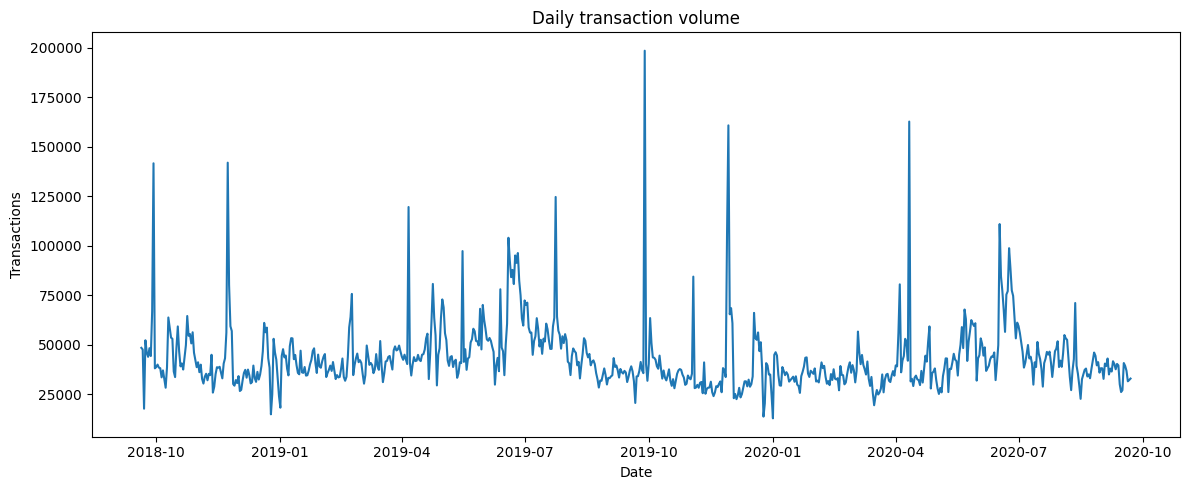

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/daily_transaction_volume.png


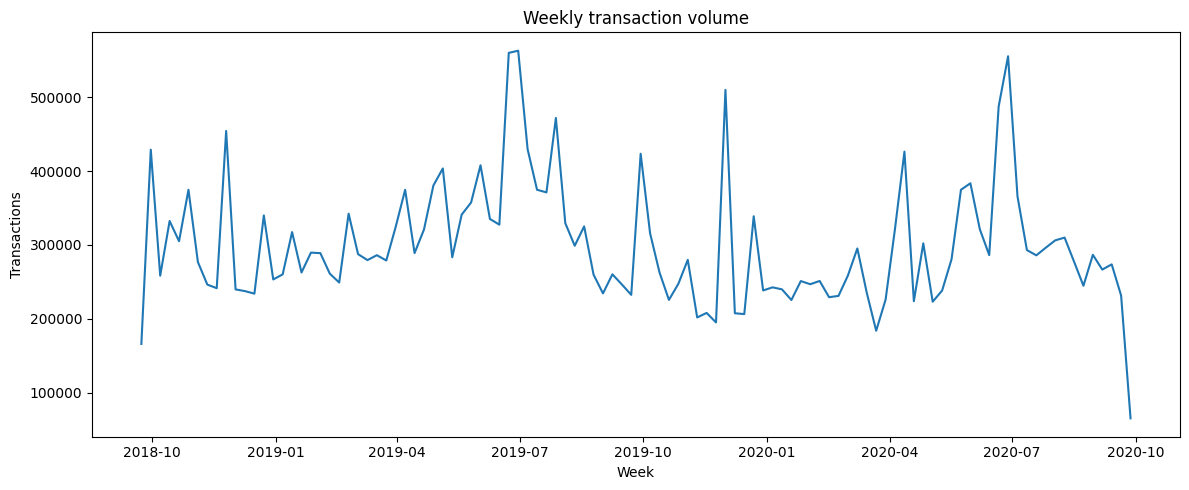

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/weekly_transaction_volume.png


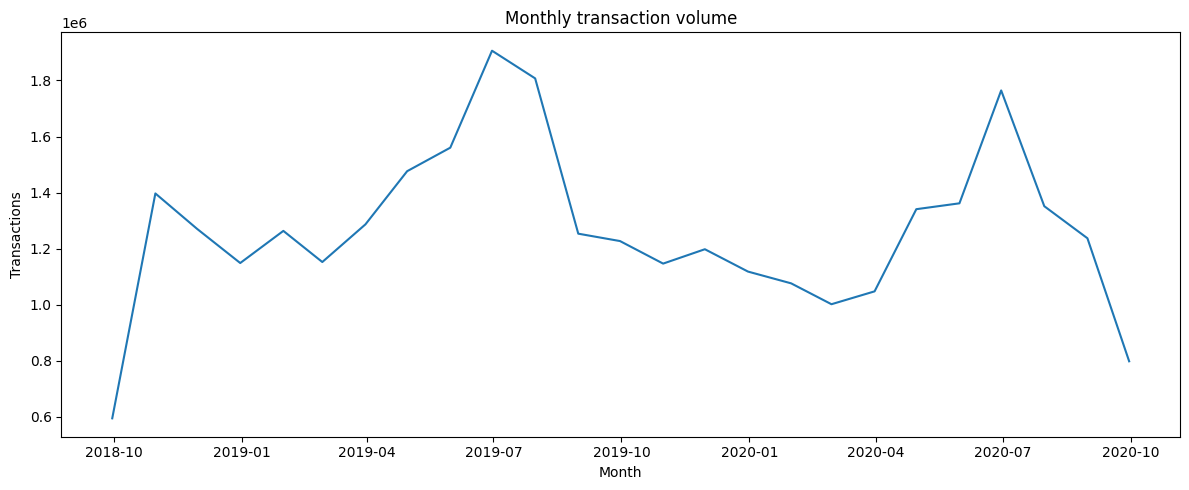

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/monthly_transaction_volume.png


In [49]:
daily_transactions = (
    interactions
    .groupby("t_dat", as_index=False)
    .size()
    .rename(columns={"size": "transactions"})
    .sort_values("t_dat")
)

weekly_transactions = (
    daily_transactions
    .set_index("t_dat")
    .resample("W")
    .sum()
    .reset_index()
)

monthly_transactions = (
    daily_transactions
    .set_index("t_dat")
    .resample("ME")
    .sum()
    .reset_index()
)

display(daily_transactions.head())
display(weekly_transactions.head())
display(monthly_transactions.head())

save_table(daily_transactions, "daily_transactions.csv")
save_table(weekly_transactions, "weekly_transactions.csv")
save_table(monthly_transactions, "monthly_transactions.csv")

plot_line(daily_transactions, "t_dat", "transactions", "Daily transaction volume", "Date", "Transactions", "daily_transaction_volume.png")
plot_line(weekly_transactions, "t_dat", "transactions", "Weekly transaction volume", "Week", "Transactions", "weekly_transaction_volume.png")
plot_line(monthly_transactions, "t_dat", "transactions", "Monthly transaction volume", "Month", "Transactions", "monthly_transaction_volume.png")

,statistic,value
0,count,1362281.000000
1,mean,23.334631
2,std,39.242253
3,min,1.000000
4,25%,3.000000
5,50%,9.000000
6,75%,27.000000
7,90%,60.000000
8,95%,91.000000
9,99%,187.000000


,customer_idx,purchase_count
0,1018839,1895
1,969180,1441
2,394603,1364
3,891429,1361
4,1098652,1237
5,459261,1208
6,1035425,1170
7,760470,1169
8,20300,1157
9,582904,1143


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/user_activity_summary.csv
Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/top_users_by_purchase_count.csv


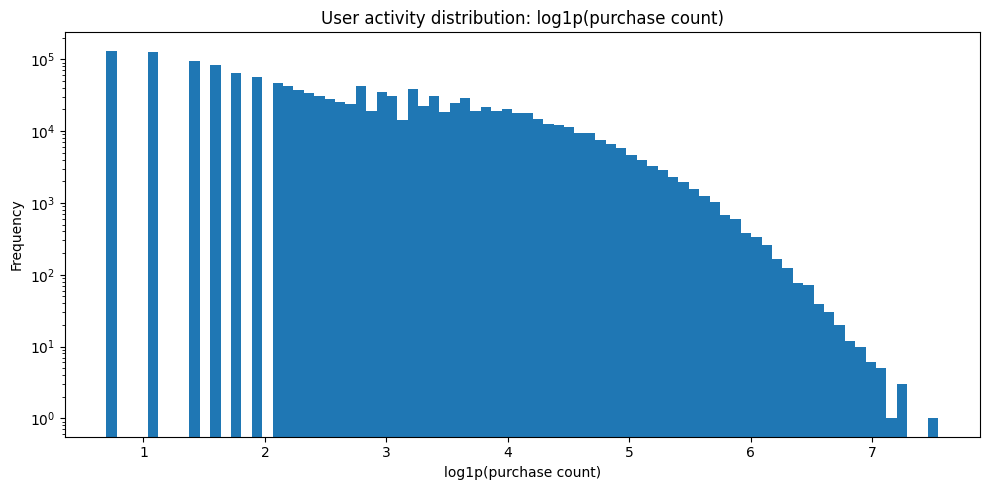

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/user_activity_log_hist.png


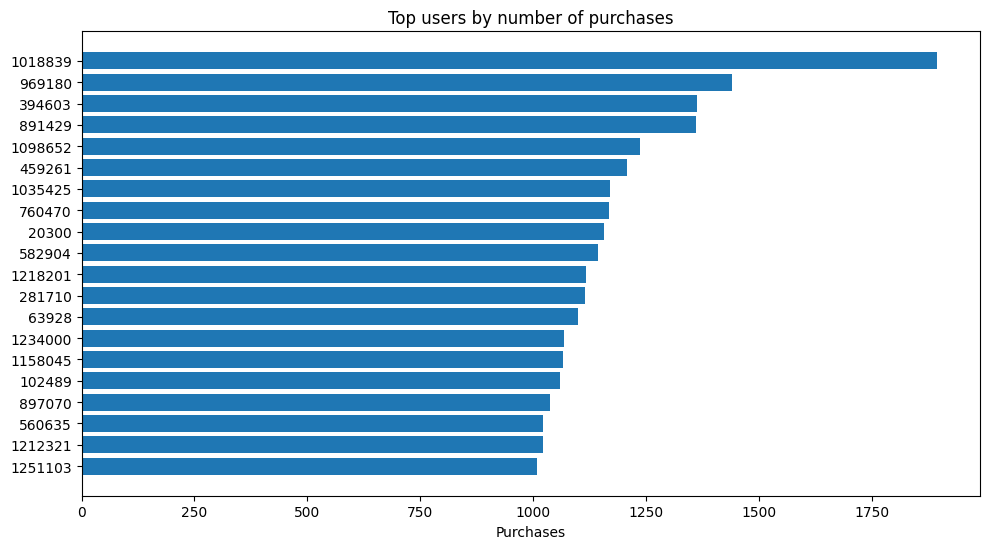

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/top_users_by_purchases.png


In [50]:
user_activity = interactions.groupby("customer_idx").size().rename("purchase_count")
user_activity_summary = user_activity.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).reset_index()
user_activity_summary.columns = ["statistic", "value"]

top_users = user_activity.sort_values(ascending=False).head(30).reset_index()
top_users.columns = ["customer_idx", "purchase_count"]

display(user_activity_summary)
display(top_users)

save_table(user_activity_summary, "user_activity_summary.csv")
save_table(top_users, "top_users_by_purchase_count.csv")

plot_hist(np.log1p(user_activity), "User activity distribution: log1p(purchase count)", "log1p(purchase count)", "user_activity_log_hist.png", bins=80, log_y=True)
plot_barh(top_users.set_index("customer_idx")["purchase_count"], "Top users by number of purchases", "Purchases", "top_users_by_purchases.png", top_n=20)

eda_summary["user_activity"] = {
    "mean_purchases_per_active_user": float(user_activity.mean()),
    "median_purchases_per_active_user": float(user_activity.median()),
    "max_purchases_by_single_user": int(user_activity.max()),
}

,statistic,value
0,count,104547.000000
1,mean,304.057735
2,std,791.266060
3,min,1.000000
4,25%,14.000000
5,50%,65.000000
6,75%,286.000000
7,90%,793.000000
8,95%,1318.000000
9,99%,3185.080000


,article_idx,purchase_count,article_id,prod_name,product_type_name,product_group_name,department_name,section_name,garment_group_name,colour_group_name
53832,53892,50287,0706016001,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,Trousers,Divided Collection,Trousers,Black
53833,53893,35043,0706016002,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,Trousers,Divided Collection,Trousers,Light Blue
1711,1713,31718,0372860001,7p Basic Shaftless,Socks,Socks & Tights,Shopbasket Socks,"Womens Nightwear, Socks & Tigh",Socks and Tights,Black
24808,24837,30199,0610776002,Tilly (1),T-shirt,Garment Upper body,Jersey Basic,Womens Everyday Basics,Jersey Basic,Black
70124,70221,26329,0759871002,Tilda tank,Vest top,Garment Upper body,EQ Divided Basics,Divided Complements Other,Jersey Basic,Black
3706,3711,25025,0464297007,Greta Thong Mynta Low 3p,Underwear bottom,Underwear,Casual Lingerie,Womens Lingerie,"Under-, Nightwear",Black
1712,1714,24458,0372860002,7p Basic Shaftless,Socks,Socks & Tights,Shopbasket Socks,"Womens Nightwear, Socks & Tigh",Socks and Tights,White
24807,24836,22451,0610776001,Tilly (1),T-shirt,Garment Upper body,Jersey Basic,Womens Everyday Basics,Jersey Basic,White
2233,2236,22236,0399223001,Curvy Jeggings HW Ankle,Trousers,Garment Lower body,Denim Trousers,Ladies Denim,Trousers Denim,Black
53834,53894,21241,0706016003,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,Trousers,Divided Collection,Trousers,Dark Blue


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/item_popularity_summary.csv
Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/top_500_items_by_purchase_count.csv


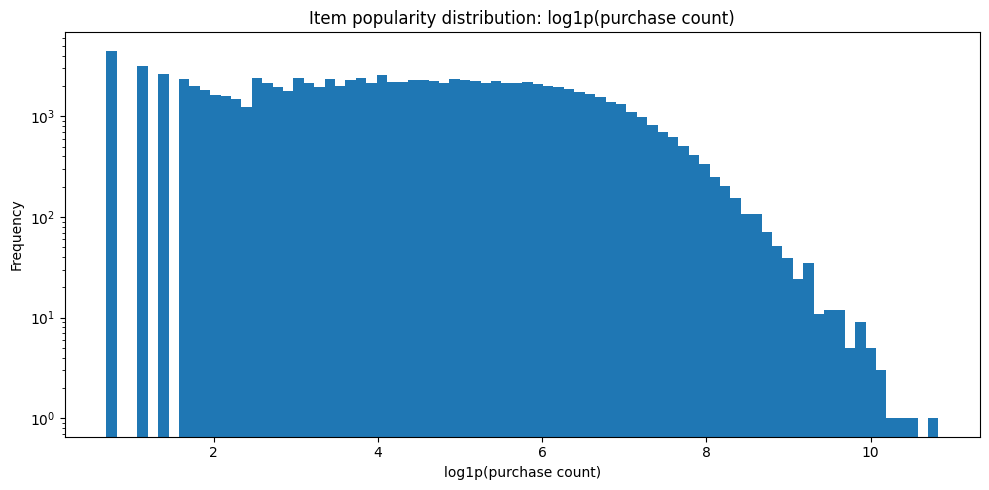

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/item_popularity_log_hist.png


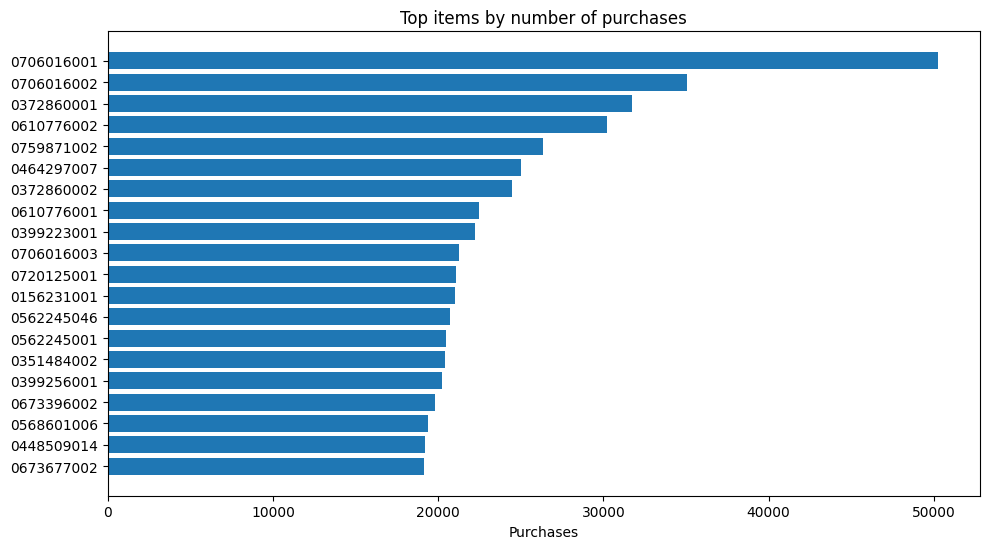

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/top_items_by_purchases.png


In [51]:
item_popularity = interactions.groupby("article_idx").size().rename("purchase_count")
item_popularity_summary = item_popularity.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).reset_index()
item_popularity_summary.columns = ["statistic", "value"]

item_popularity_df = item_popularity.reset_index().merge(
    articles[[
        "article_idx", "article_id", "prod_name", "product_type_name",
        "product_group_name", "department_name", "section_name",
        "garment_group_name", "colour_group_name"
    ]],
    on="article_idx",
    how="left",
)

item_popularity_df = item_popularity_df.sort_values("purchase_count", ascending=False)

display(item_popularity_summary)
display(item_popularity_df.head(30))

save_table(item_popularity_summary, "item_popularity_summary.csv")
save_table(item_popularity_df.head(500), "top_500_items_by_purchase_count.csv")

plot_hist(np.log1p(item_popularity), "Item popularity distribution: log1p(purchase count)", "log1p(purchase count)", "item_popularity_log_hist.png", bins=80, log_y=True)
plot_barh(item_popularity_df.head(20).set_index("article_id")["purchase_count"], "Top items by number of purchases", "Purchases", "top_items_by_purchases.png", top_n=20)

eda_summary["item_popularity"] = {
    "mean_purchases_per_active_item": float(item_popularity.mean()),
    "median_purchases_per_active_item": float(item_popularity.median()),
    "max_purchases_by_single_item": int(item_popularity.max()),
}

,metric,value
0,unique_customer_article_pairs,27306439.000000
1,repeat_customer_article_pairs,3515413.000000
2,repeat_pair_percent,12.873934
3,events_from_repeat_pairs,7997298.000000
4,events_from_repeat_pairs_percent,25.157940
5,max_repeat_count_for_customer_article_pair,570.000000


,customer_idx,article_idx,purchase_count,first_purchase_date,last_purchase_date,avg_price,implicit_weight,article_id,prod_name,product_type_name,product_group_name
0,1114704,43839,570.000000,2018-10-14,2018-10-14,0.006766,7.347389,0678342001,Lima SS.,T-shirt,Garment Upper body
1,794923,30651,199.000000,2019-02-16,2019-02-16,0.008458,6.298317,0629420001,claudine,T-shirt,Garment Upper body
2,524057,6641,188.000000,2019-02-21,2019-04-15,0.022883,6.241747,0507909001,Rebecca or Delphine shirt,Shirt,Garment Upper body
3,1281825,16452,170.000000,2019-01-17,2019-02-04,0.012189,6.141664,0570002001,ROY SLIM RN T-SHIRT,T-shirt,Garment Upper body
4,496461,47313,166.000000,2019-09-25,2019-09-28,0.014464,6.117994,0688558002,Brittany LS,Top,Garment Upper body
5,1263310,46086,130.000000,2019-04-15,2019-04-15,0.015890,5.875197,0685347001,Duo,Top,Garment Upper body
6,1106429,16534,124.000000,2019-06-11,2019-07-04,0.016236,5.828314,0570004009,PETER POLO,Polo shirt,Garment Upper body
7,768003,187,120.000000,2019-02-11,2019-02-11,0.013542,5.795791,0189634001,Long Leg Leggings,Leggings/Tights,Garment Lower body
8,7063,69118,120.000000,2019-10-16,2019-10-16,0.025407,5.795791,0756322001,Lindsay N-slip (W),Night gown,Nightwear
9,1144654,115,120.000000,2018-12-25,2020-07-02,0.015345,5.795791,0179123001,Long Leggings,Leggings/Tights,Garment Lower body


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/repeat_purchase_summary.csv
Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/top_repeat_customer_article_pairs.csv


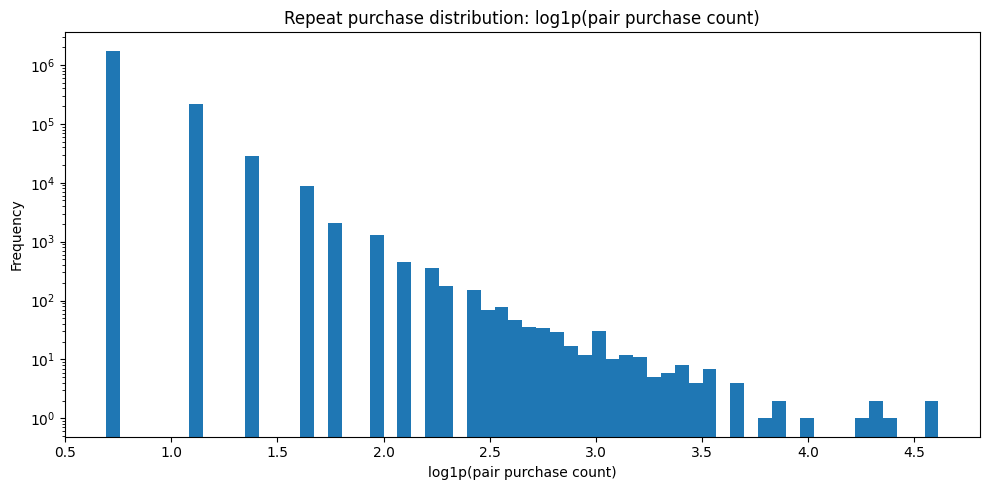

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/repeat_purchase_pair_log_hist.png


In [52]:
repeat_pairs = interactions_agg[interactions_agg["purchase_count"] > 1].copy()

repeat_summary = pd.DataFrame([
    {"metric": "unique_customer_article_pairs", "value": len(interactions_agg)},
    {"metric": "repeat_customer_article_pairs", "value": len(repeat_pairs)},
    {"metric": "repeat_pair_percent", "value": len(repeat_pairs) / max(len(interactions_agg), 1) * 100},
    {"metric": "events_from_repeat_pairs", "value": float(repeat_pairs["purchase_count"].sum())},
    {"metric": "events_from_repeat_pairs_percent", "value": float(repeat_pairs["purchase_count"].sum() / interactions_agg["purchase_count"].sum() * 100)},
    {"metric": "max_repeat_count_for_customer_article_pair", "value": float(interactions_agg["purchase_count"].max())},
])

top_repeat_pairs = interactions_agg.sort_values("purchase_count", ascending=False).head(50).merge(
    articles[["article_idx", "article_id", "prod_name", "product_type_name", "product_group_name"]],
    on="article_idx",
    how="left",
)

display(repeat_summary)
display(top_repeat_pairs.head(20))

save_table(repeat_summary, "repeat_purchase_summary.csv")
save_table(top_repeat_pairs, "top_repeat_customer_article_pairs.csv")

plot_hist(np.log1p(interactions_agg["purchase_count"]), "Repeat purchase distribution: log1p(pair purchase count)", "log1p(pair purchase count)", "repeat_purchase_pair_log_hist.png", bins=60, log_y=True)

eda_summary["repeat_purchase"] = repeat_summary.to_dict(orient="records")

,statistic,value
0,count,31788324.000000
1,mean,0.027829
2,std,0.018332
3,min,0.000017
4,1%,0.003576
5,5%,0.007610
6,25%,0.015814
7,50%,0.025407
8,75%,0.033881
9,95%,0.059305


,sales_channel_id,transactions,percent
0,1,9408462,29.597226
1,2,22379862,70.402774


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/price_summary.csv
Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/sales_channel_distribution.csv


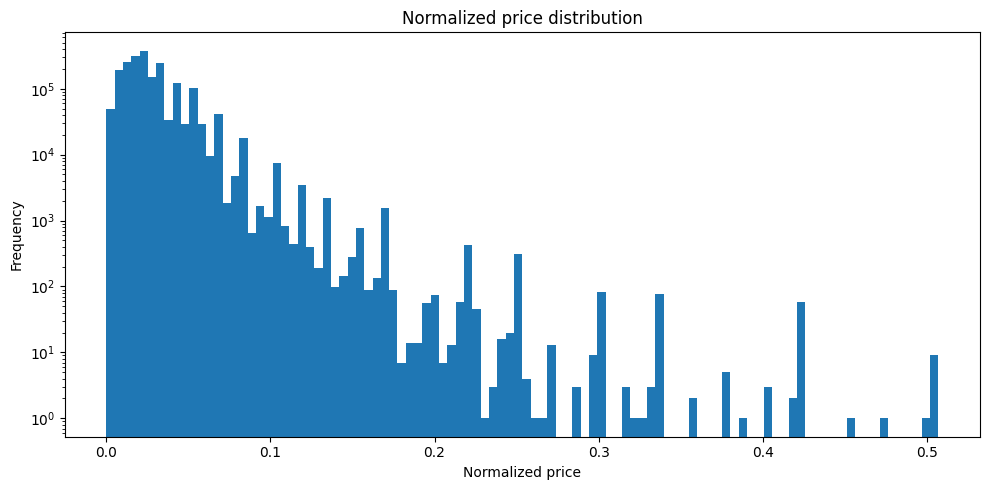

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/price_distribution.png


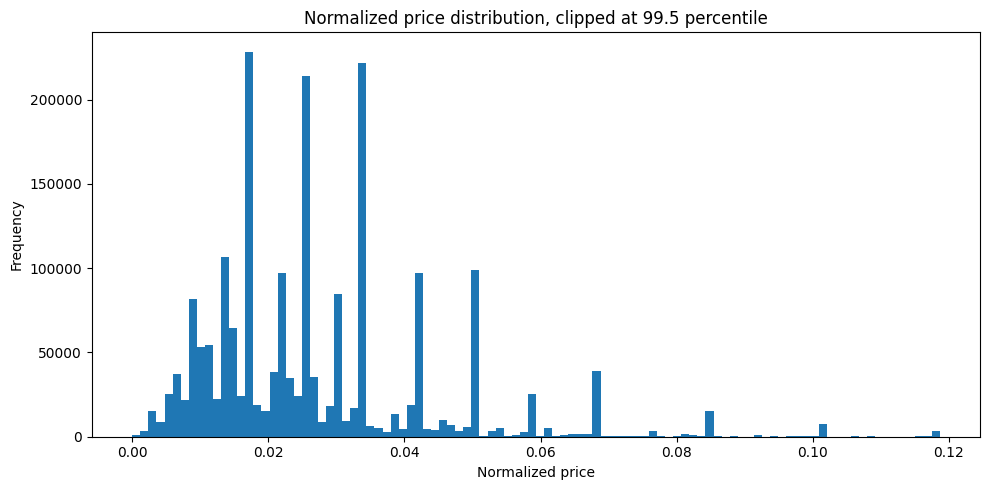

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/price_distribution_clipped_995.png


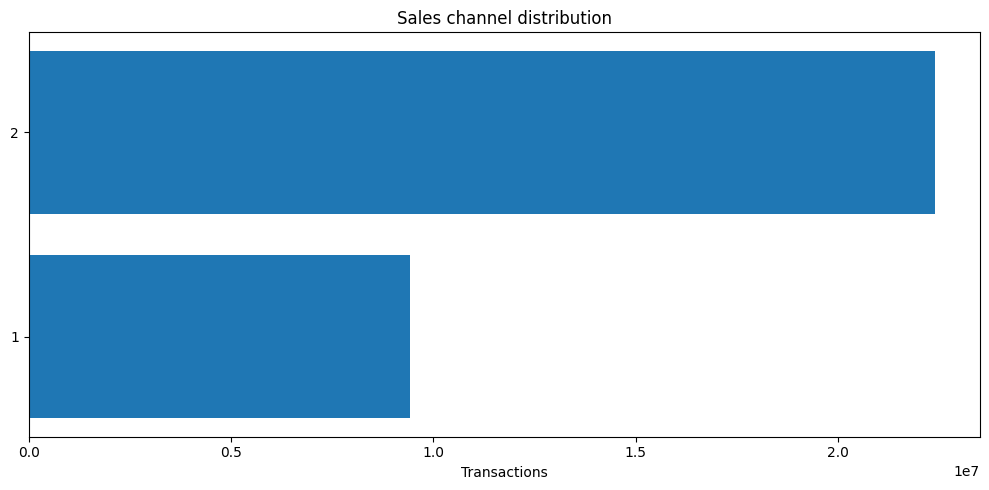

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/sales_channel_distribution.png


In [53]:
price_summary = interactions["price"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).reset_index()
price_summary.columns = ["statistic", "value"]

sales_channel_counts = interactions["sales_channel_id"].value_counts().sort_index().reset_index()
sales_channel_counts.columns = ["sales_channel_id", "transactions"]
sales_channel_counts["percent"] = sales_channel_counts["transactions"] / len(interactions) * 100

display(price_summary)
display(sales_channel_counts)

save_table(price_summary, "price_summary.csv")
save_table(sales_channel_counts, "sales_channel_distribution.csv")

price_values = interactions["price"].dropna()
plot_hist(price_values, "Normalized price distribution", "Normalized price", "price_distribution.png", bins=100, log_y=True)

upper_price = price_values.quantile(0.995)
plot_hist(price_values[price_values <= upper_price], "Normalized price distribution, clipped at 99.5 percentile", "Normalized price", "price_distribution_clipped_995.png", bins=100, log_y=False)

plot_barh(sales_channel_counts.set_index("sales_channel_id")["transactions"], "Sales channel distribution", "Transactions", "sales_channel_distribution.png", top_n=10)

eda_summary["price"] = {
    "mean_price": float(interactions["price"].mean()),
    "median_price": float(interactions["price"].median()),
    "max_price": float(interactions["price"].max()),
}

,product_group_name,count,percent
0,Garment Upper body,42741,40.496700
1,Garment Lower body,19812,18.771700
2,Garment Full body,13292,12.594000
3,Accessories,11158,10.572100
4,Underwear,5490,5.201700
5,Shoes,5283,5.005600
6,Swimwear,3127,2.962800
7,Socks & Tights,2442,2.313800
8,Nightwear,1899,1.799300
9,Unknown,121,0.114600


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/article_distribution_product_group_name.csv


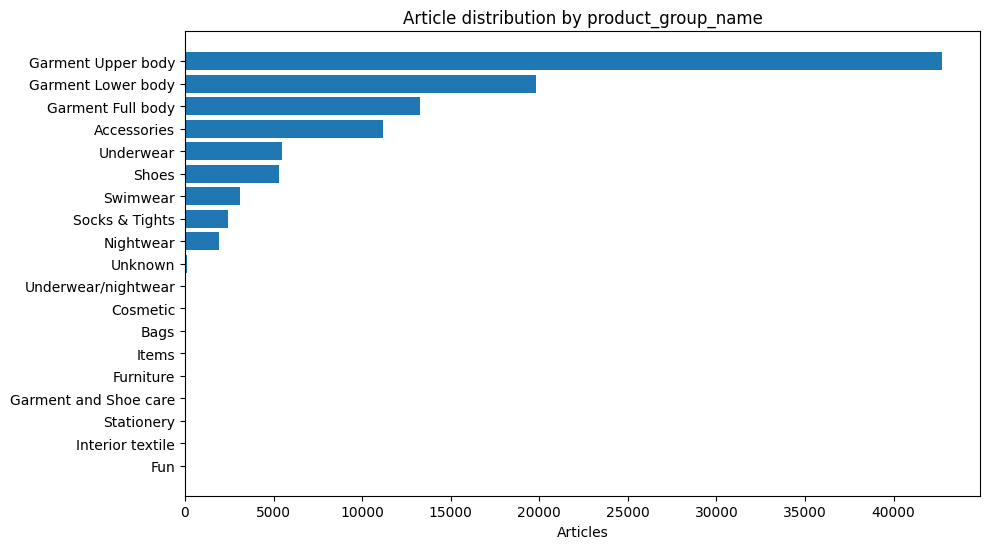

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/article_distribution_product_group_name.png


,product_type_name,count,percent
0,Trousers,11169,10.582500
1,Dress,10362,9.817900
2,Sweater,9302,8.813600
3,T-shirt,7904,7.489000
4,Top,4155,3.936800
5,Blouse,3979,3.770100
6,Jacket,3940,3.733100
7,Shorts,3939,3.732200
8,Shirt,3405,3.226200
9,Vest top,2991,2.833900


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/article_distribution_product_type_name.csv


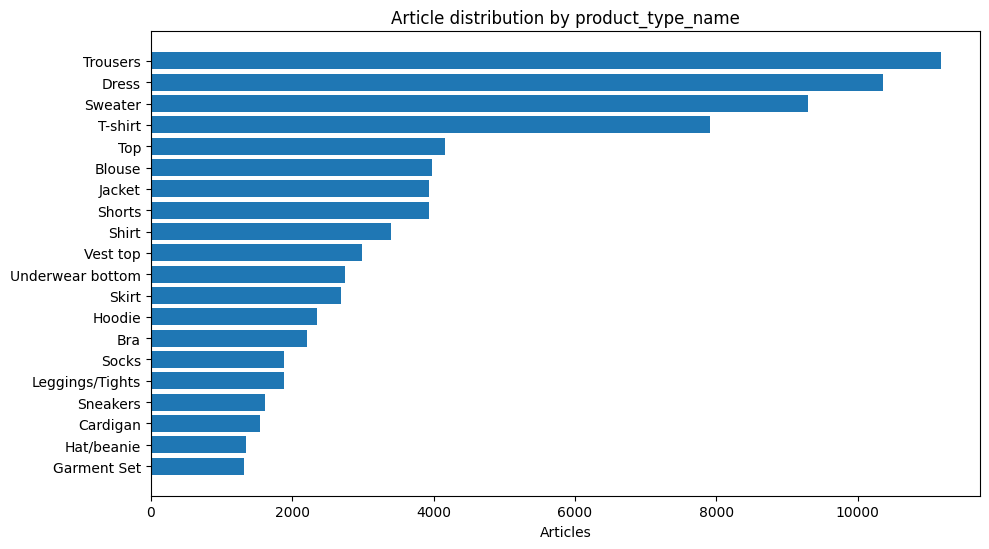

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/article_distribution_product_type_name.png


,garment_group_name,count,percent
0,Jersey Fancy,21445,20.318900
1,Accessories,11519,10.914100
2,Jersey Basic,8126,7.699300
3,Knitwear,7490,7.096700
4,"Under-, Nightwear",7441,7.050300
5,Trousers,6727,6.373800
6,Blouses,5838,5.531400
7,Shoes,5145,4.874800
8,Dresses Ladies,4874,4.618100
9,Outdoor,4501,4.264700


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/article_distribution_garment_group_name.csv


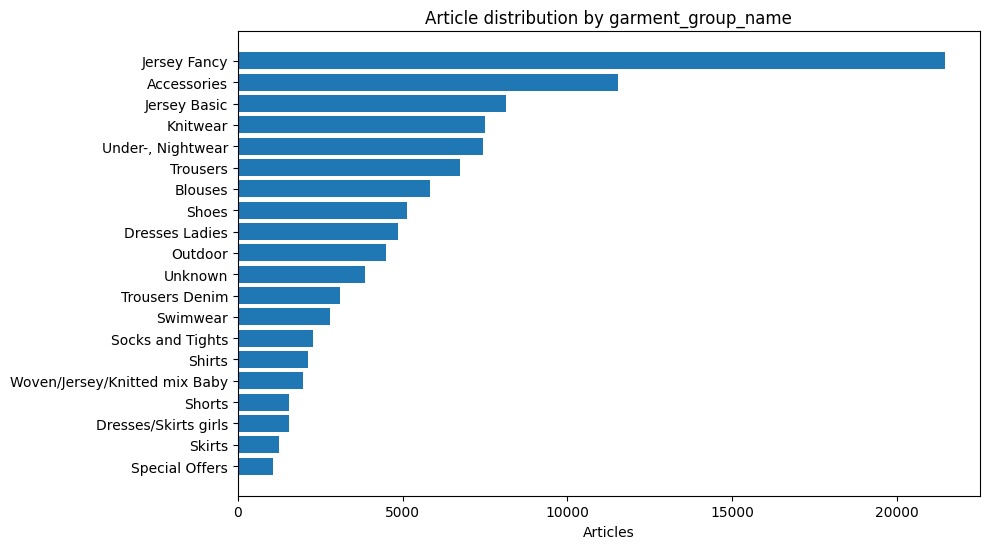

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/article_distribution_garment_group_name.png


,section_name,count,percent
0,Womens Everyday Collection,7295,6.911900
1,Divided Collection,7124,6.749900
2,Baby Essentials & Complements,4932,4.673000
3,Kids Girl,4469,4.234300
4,Young Girl,3899,3.694300
5,Womens Lingerie,3598,3.409100
6,Girls Underwear & Basics,3490,3.306700
7,Womens Tailoring,3376,3.198700
8,Kids Boy,3328,3.153200
9,Womens Small accessories,3270,3.098300


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/article_distribution_section_name.csv


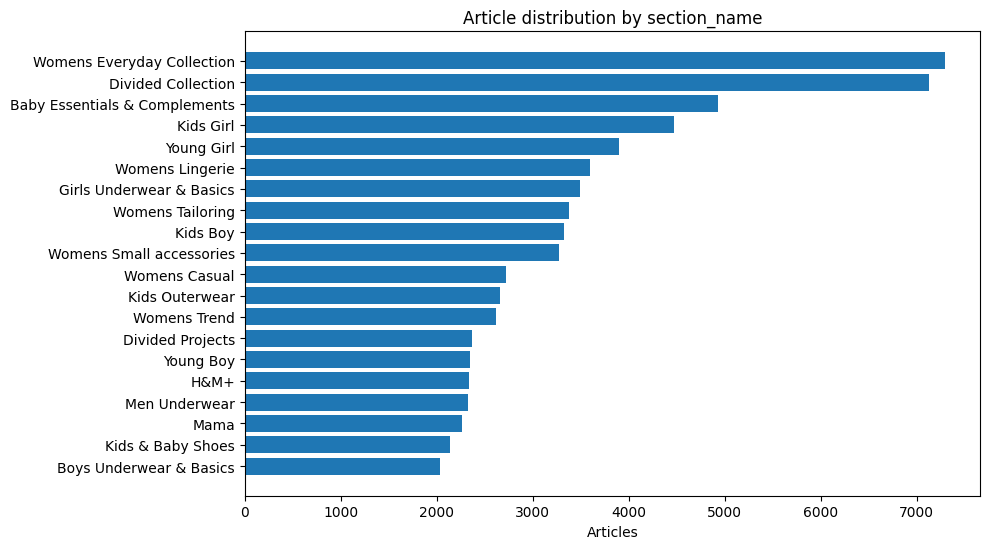

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/article_distribution_section_name.png


,index_group_name,count,percent
0,Ladieswear,39737,37.650400
1,Baby/Children,34711,32.888300
2,Divided,15149,14.353500
3,Menswear,12553,11.893800
4,Sport,3392,3.213900


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/article_distribution_index_group_name.csv


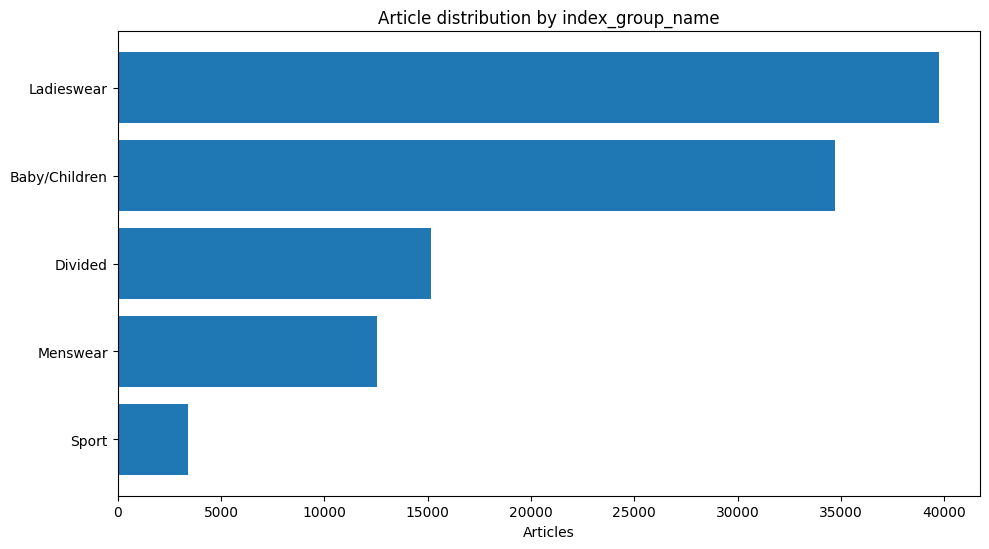

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/article_distribution_index_group_name.png


,department_name,count,percent
0,Jersey,4604,4.362200
1,Knitwear,3503,3.319100
2,Trouser,2655,2.515600
3,Blouse,2362,2.238000
4,Dress,2087,1.977400
5,Swimwear,2075,1.966000
6,Kids Girl Jersey Fancy,2032,1.925300
7,Expressive Lingerie,1921,1.820100
8,Young Girl Jersey Fancy,1874,1.775600
9,Jersey Fancy,1754,1.661900


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/article_distribution_department_name.csv


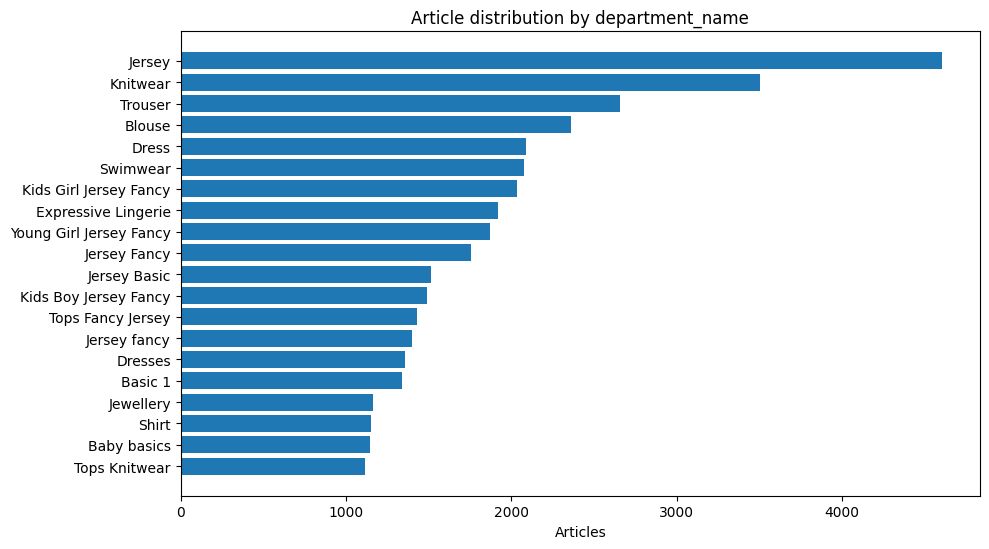

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/article_distribution_department_name.png


,colour_group_name,count,percent
0,Black,22670,21.479600
1,Dark Blue,12171,11.531900
2,White,9542,9.041000
3,Light Pink,5811,5.505900
4,Grey,4487,4.251400
5,Light Beige,3356,3.179800
6,Blue,3308,3.134300
7,Red,3056,2.895500
8,Light Blue,3012,2.853800
9,Greenish Khaki,2767,2.621700


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/article_distribution_colour_group_name.csv


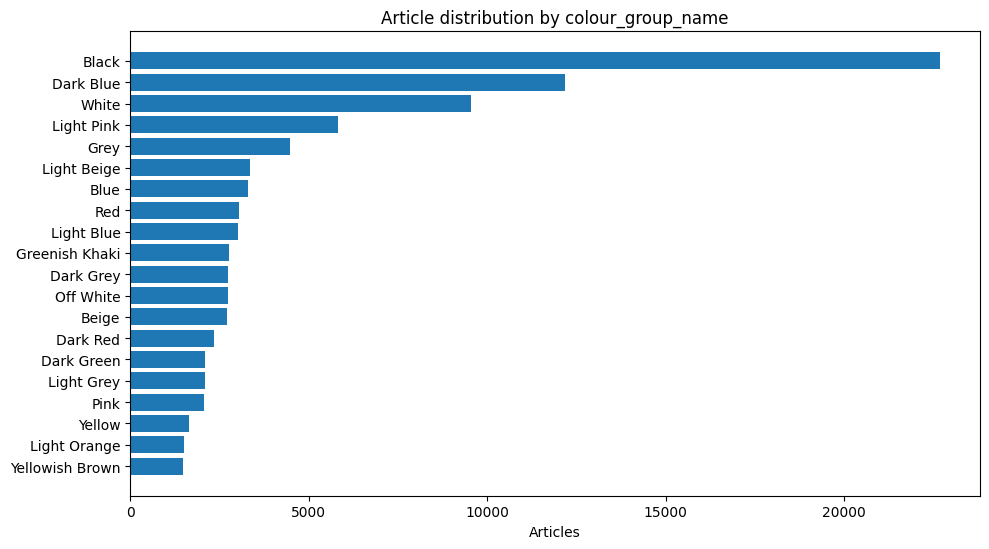

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/article_distribution_colour_group_name.png


,perceived_colour_master_name,count,percent
0,Black,22585,21.399100
1,Blue,18469,17.499200
2,White,12665,12.000000
3,Pink,9403,8.909200
4,Grey,8924,8.455400
5,Red,5878,5.569300
6,Beige,5657,5.360000
7,Green,3526,3.340900
8,Khaki green,3181,3.014000
9,Yellow,3121,2.957100


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/article_distribution_perceived_colour_master_name.csv


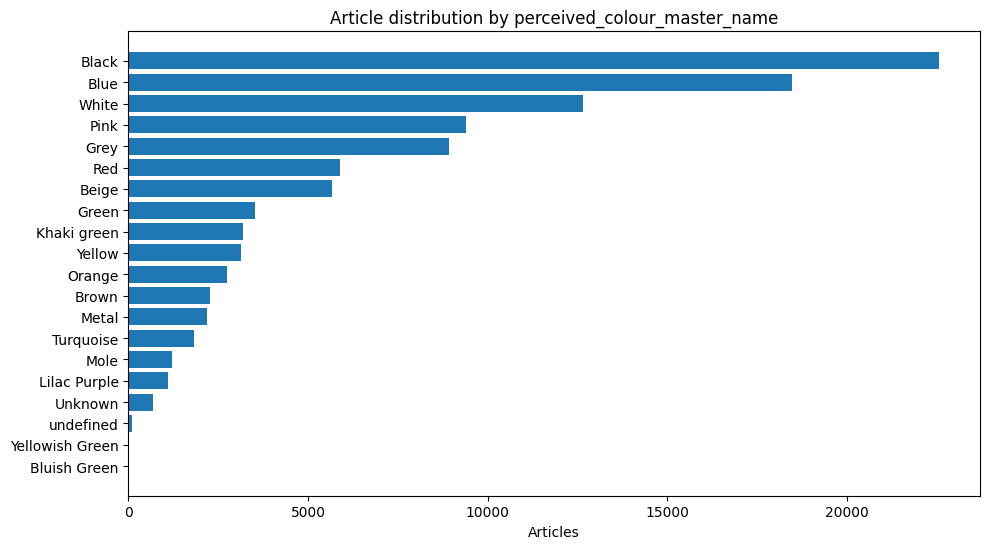

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/article_distribution_perceived_colour_master_name.png


,graphical_appearance_name,count,percent
0,Solid,49747,47.134800
1,All over pattern,17165,16.263700
2,Melange,5938,5.626200
3,Stripe,4990,4.728000
4,Denim,4842,4.587700
5,Front print,3215,3.046200
6,Placement print,3098,2.935300
7,Check,2178,2.063600
8,Colour blocking,1830,1.733900
9,Lace,1513,1.433600


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/article_distribution_graphical_appearance_name.csv


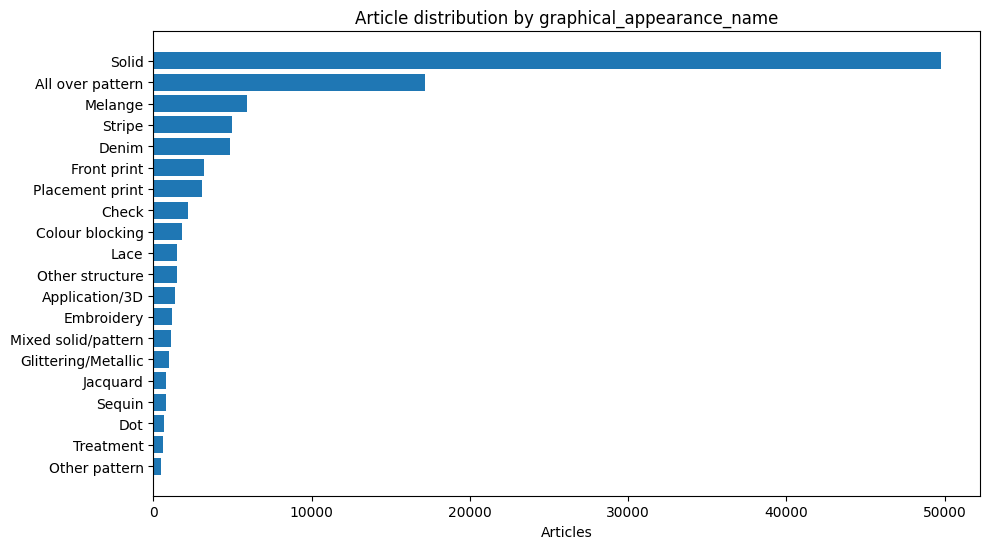

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/article_distribution_graphical_appearance_name.png


In [54]:
article_metadata_columns = [
    "product_group_name",
    "product_type_name",
    "garment_group_name",
    "section_name",
    "index_group_name",
    "department_name",
    "colour_group_name",
    "perceived_colour_master_name",
    "graphical_appearance_name",
]

for col in article_metadata_columns:
    if col not in articles.columns:
        continue

    table = value_counts_table(articles, col, top_n=50)
    display(table.head(20))
    save_table(table, f"article_distribution_{col}.csv")
    plot_barh(table.set_index(col)["count"], f"Article distribution by {col}", "Articles", f"article_distribution_{col}.png", top_n=20)

,statistic,value
0,count,1356119.000000
1,mean,36.386965
2,std,14.313628
3,min,16.000000
4,1%,18.000000
5,5%,19.000000
6,25%,24.000000
7,50%,32.000000
8,75%,49.000000
9,95%,62.000000


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/customer_age_summary.csv


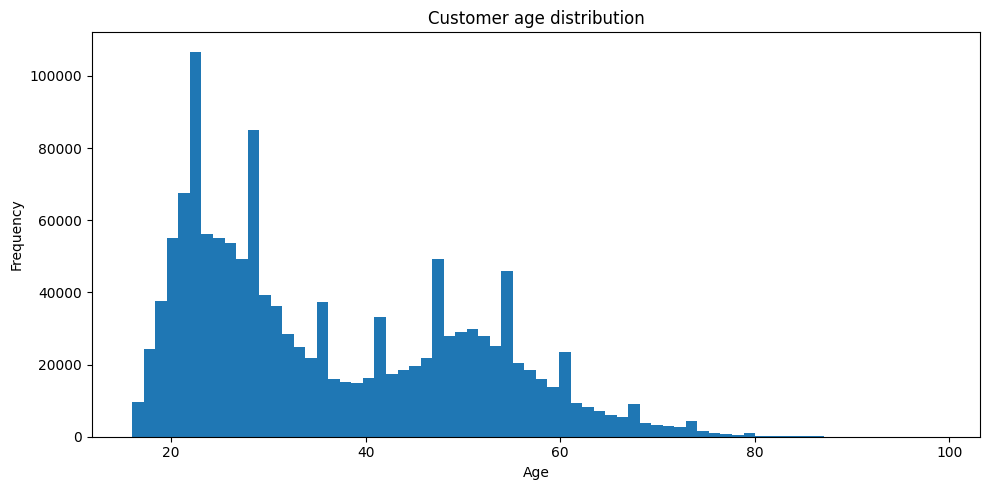

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/customer_age_distribution.png


,club_member_status,count,percent
0,ACTIVE,1272491,92.748500
1,PRE-CREATE,92960,6.775600
2,UNKNOWN,6062,0.441800
3,LEFT CLUB,467,0.034000


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/customer_distribution_club_member_status.csv


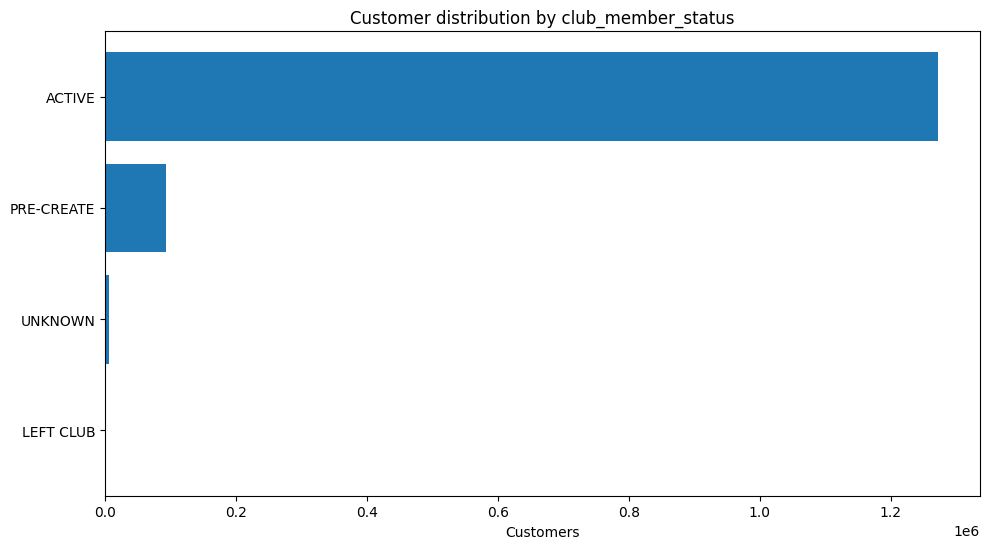

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/customer_distribution_club_member_status.png


,fashion_news_frequency,count,percent
0,NONE,877711,63.974000
1,REGULARLY,477416,34.797600
2,UNKNOWN,16011,1.167000
3,MONTHLY,842,0.061400


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/customer_distribution_fashion_news_frequency.csv


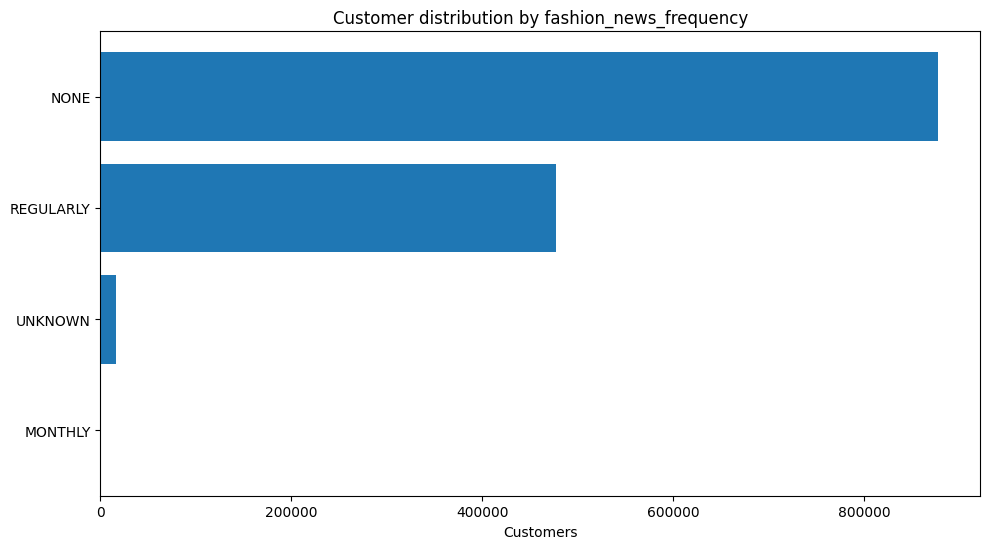

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/customer_distribution_fashion_news_frequency.png


,FN,count,percent
0,0,895050,65.237800
1,1,476930,34.762200


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/customer_distribution_FN.csv


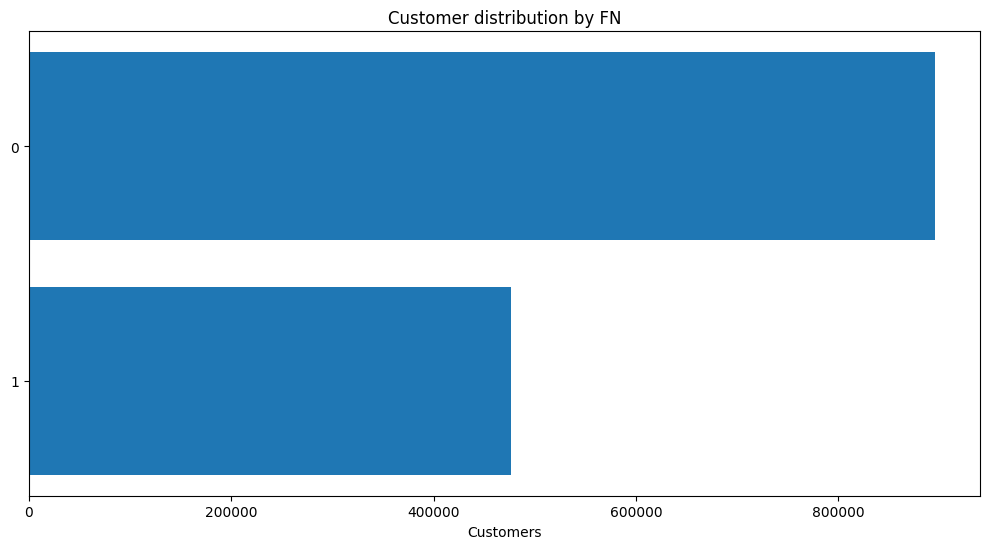

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/customer_distribution_FN.png


,Active,count,percent
0,0,907576,66.150800
1,1,464404,33.849200


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/customer_distribution_Active.csv


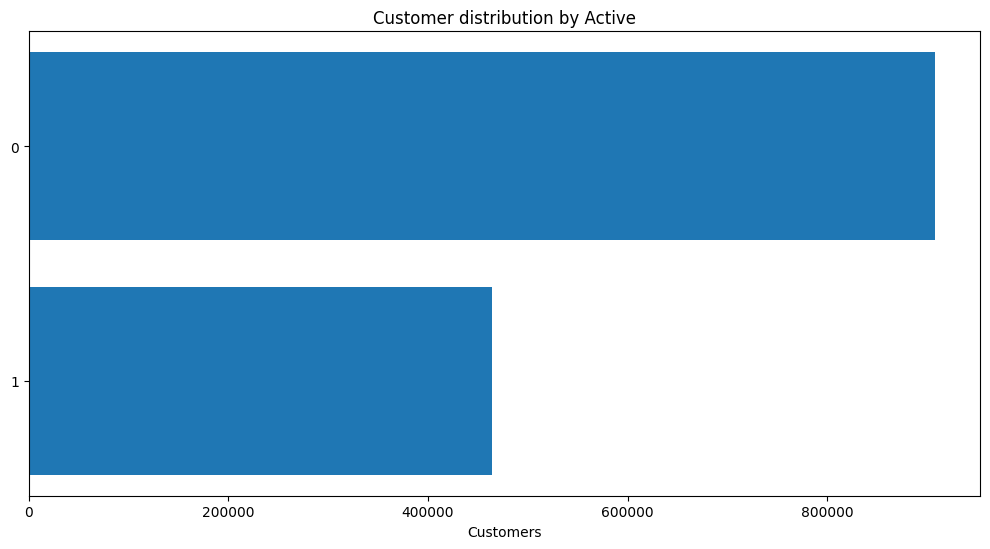

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/customer_distribution_Active.png


In [55]:
if "age" in customers.columns:
    age_summary = customers["age"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).reset_index()
    age_summary.columns = ["statistic", "value"]
    display(age_summary)
    save_table(age_summary, "customer_age_summary.csv")
    plot_hist(customers["age"], "Customer age distribution", "Age", "customer_age_distribution.png", bins=70, log_y=False)

customer_metadata_columns = ["club_member_status", "fashion_news_frequency", "FN", "Active"]

for col in customer_metadata_columns:
    if col not in customers.columns:
        continue
    table = value_counts_table(customers, col, top_n=30)
    display(table)
    save_table(table, f"customer_distribution_{col}.csv")
    plot_barh(table.set_index(col)["count"], f"Customer distribution by {col}", "Customers", f"customer_distribution_{col}.png", top_n=20)

,product_group_name,total_purchases,unique_articles,avg_purchases_per_article,median_purchases_per_article
7,Garment Upper body,12552755,42313,296.664264,67.000000
6,Garment Lower body,7046054,19661,358.377193,64.000000
5,Garment Full body,3552470,13160,269.944529,71.000000
15,Swimwear,2579222,3127,824.823153,199.000000
16,Underwear,2565858,5447,471.058932,203.000000
0,Accessories,1599593,11023,145.114125,49.000000
12,Shoes,745521,5228,142.601568,30.000000
13,Socks & Tights,685712,2420,283.352066,34.000000
11,Nightwear,348180,1882,185.005313,34.000000
18,Unknown,97040,113,858.761062,312.000000


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/purchase_popularity_by_product_group_name.csv


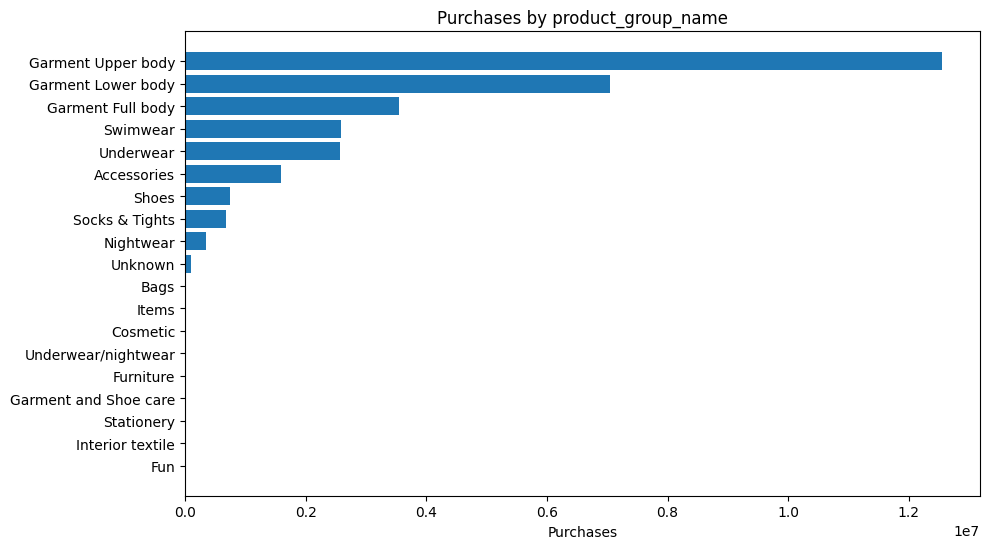

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/purchases_by_product_group_name.png


,product_type_name,total_purchases,unique_articles,avg_purchases_per_article,median_purchases_per_article
111,Trousers,4217017,11060,381.285443,64.000000
32,Dress,3238428,10266,315.451783,112.000000
99,Sweater,2783274,9173,303.420255,84.000000
104,T-shirt,2203750,7873,279.912359,42.000000
107,Top,1583408,4104,385.820663,106.000000
11,Blouse,1504868,3941,381.849277,143.000000
120,Vest top,1414101,2987,473.418480,106.000000
15,Bra,1335233,2197,607.752845,343.000000
86,Shorts,1152513,3937,292.738887,49.000000
8,Bikini top,1126202,850,1324.943529,776.500000


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/purchase_popularity_by_product_type_name.csv


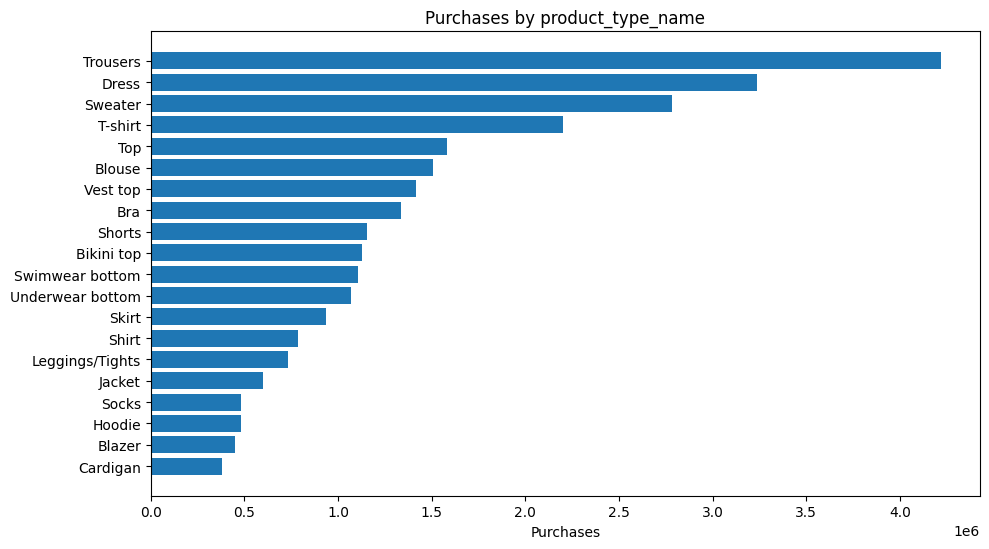

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/purchases_by_product_type_name.png


,garment_group_name,total_purchases,unique_articles,avg_purchases_per_article,median_purchases_per_article
6,Jersey Fancy,5171611,21265,243.198260,55.000000
5,Jersey Basic,3268451,8075,404.761734,46.000000
18,"Under-, Nightwear",2966788,7377,402.167277,132.000000
16,Trousers,2953711,6669,442.901634,94.000000
15,Swimwear,2538085,2787,910.687119,280.000000
1,Blouses,2510441,5796,433.133368,195.000000
7,Knitwear,2392807,7377,324.360445,82.000000
3,Dresses Ladies,2147529,4839,443.796032,243.000000
0,Accessories,1645464,11380,144.592619,47.000000
17,Trousers Denim,1279886,3074,416.358491,88.000000


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/purchase_popularity_by_garment_group_name.csv


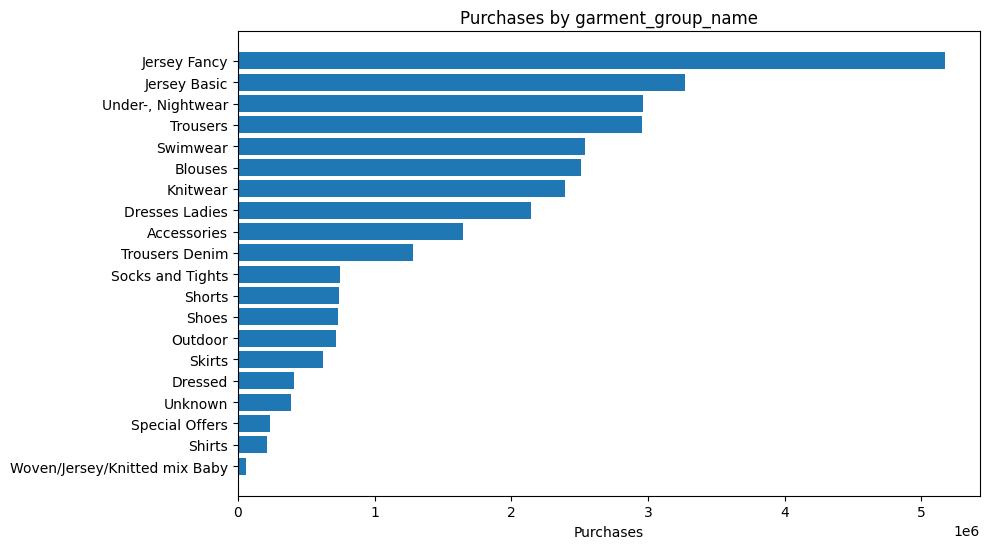

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/purchases_by_garment_group_name.png


,section_name,total_purchases,unique_articles,avg_purchases_per_article,median_purchases_per_article
44,Womens Everyday Collection,5860832,7235,810.066621,475.000000
12,Divided Collection,3768107,7078,532.368890,319.000000
51,"Womens Swimwear, beachwear",2455138,1839,1335.039695,801.000000
46,Womens Lingerie,2200139,3576,615.251398,366.000000
52,Womens Tailoring,2133999,3334,640.071686,380.000000
43,Womens Everyday Basics,1541864,1580,975.863291,466.500000
11,Divided Basics,1290216,1723,748.819501,342.000000
42,Womens Casual,1228424,2699,455.140422,298.000000
27,Ladies H&M Sport,1177490,1890,623.010582,309.000000
47,"Womens Nightwear, Socks & Tigh",1110181,1548,717.171189,327.000000


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/purchase_popularity_by_section_name.csv


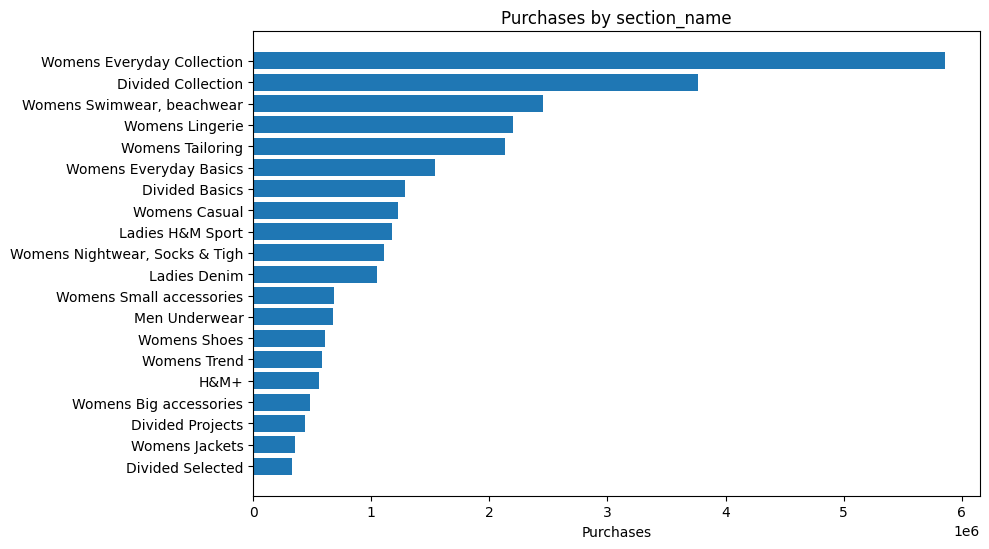

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/purchases_by_section_name.png


,department_name,total_purchases,unique_articles,avg_purchases_per_article,median_purchases_per_article
195,Swimwear,2495122,2075,1202.468434,639.000000
208,Trouser,1742298,2638,660.461713,213.500000
33,Blouse,1651060,2342,704.978651,417.000000
124,Knitwear,1598097,3441,464.428073,163.000000
81,Jersey,1526503,4560,334.759430,167.500000
82,Jersey Basic,1469357,1513,971.154660,428.000000
66,Expressive Lingerie,1196062,1907,627.195595,433.000000
87,Jersey fancy,1156697,1390,832.156115,507.000000
27,Basic 1,1140599,1339,851.828977,410.000000
54,Dress,1114750,2065,539.830508,314.000000


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/purchase_popularity_by_department_name.csv


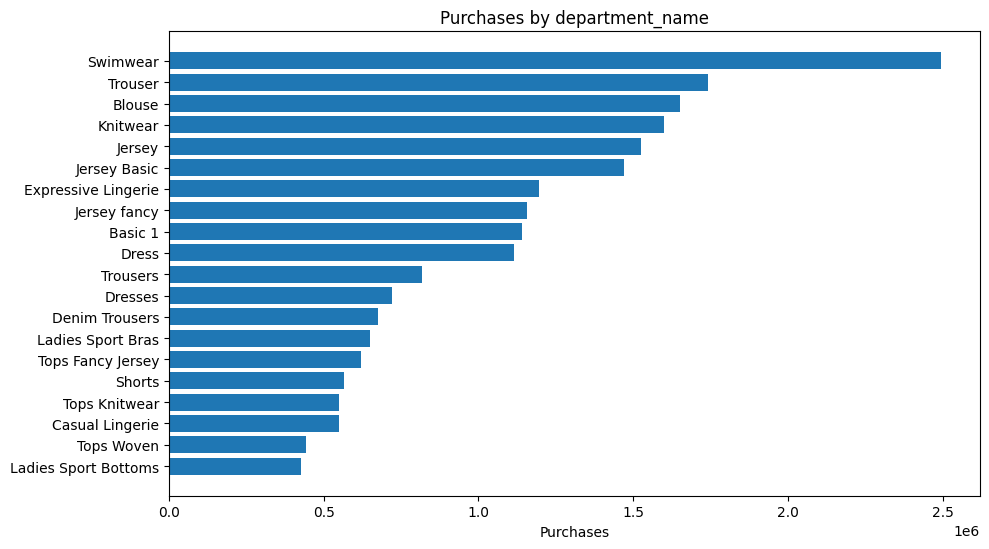

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/purchases_by_department_name.png


,colour_group_name,total_purchases,unique_articles,avg_purchases_per_article,median_purchases_per_article
1,Black,11036956,22389,492.963330,133.000000
47,White,3368276,9517,353.922034,75.000000
5,Dark Blue,2180620,12115,179.993397,33.000000
19,Light Beige,1263385,3314,381.226614,115.000000
2,Blue,1088455,3294,330.435641,60.000000
0,Beige,921184,2672,344.754491,146.000000
20,Light Blue,913496,3005,303.992013,64.000000
24,Light Pink,858234,5766,148.843913,29.000000
29,Off White,841673,2706,311.039542,89.000000
17,Grey,840065,4445,188.991001,39.000000


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/purchase_popularity_by_colour_group_name.csv


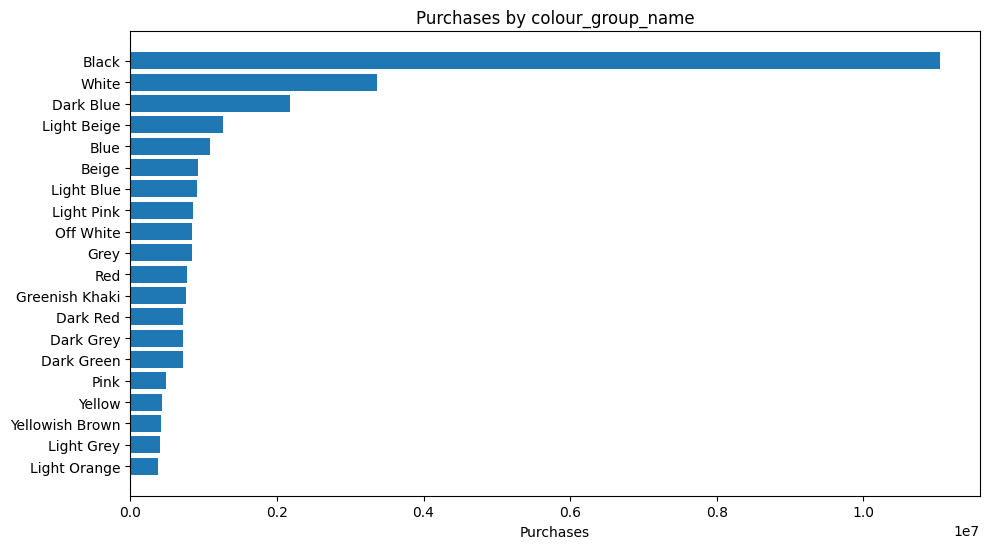

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/purchases_by_colour_group_name.png


In [56]:
metadata_for_popularity = [
    "product_group_name",
    "product_type_name",
    "garment_group_name",
    "section_name",
    "index_group_name",
    "department_name",
    "colour_group_name",
]

for col in metadata_for_popularity:
    if col not in item_popularity_df.columns:
        continue

    popularity_table = (
        item_popularity_df
        .groupby(col, dropna=False)
        .agg(
            total_purchases=("purchase_count", "sum"),
            unique_articles=("article_idx", "nunique"),
            avg_purchases_per_article=("purchase_count", "mean"),
            median_purchases_per_article=("purchase_count", "median"),
        )
        .reset_index()
        .sort_values("total_purchases", ascending=False)
    )

    display(popularity_table.head(20))
    save_table(popularity_table, f"purchase_popularity_by_{col}.csv")
    plot_barh(popularity_table.set_index(col)["total_purchases"], f"Purchases by {col}", "Purchases", f"purchases_by_{col}.png", top_n=20)

,product_group_name,sample_transactions,avg_price,median_price,p95_price
6,Garment Upper body,789678,0.026955,0.022017,0.067780
5,Garment Lower body,443372,0.032914,0.033288,0.065322
4,Garment Full body,223313,0.036148,0.033881,0.067780
14,Swimwear,162268,0.022350,0.022017,0.042356
15,Underwear,161553,0.021223,0.020949,0.039661
0,Accessories,100648,0.015540,0.013542,0.033881
11,Shoes,47184,0.038742,0.033881,0.084729
12,Socks & Tights,43109,0.011407,0.012186,0.017610
10,Nightwear,21920,0.025408,0.025407,0.042356
17,Unknown,5959,0.026690,0.025407,0.042356


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/sample_price_by_product_group_name.csv


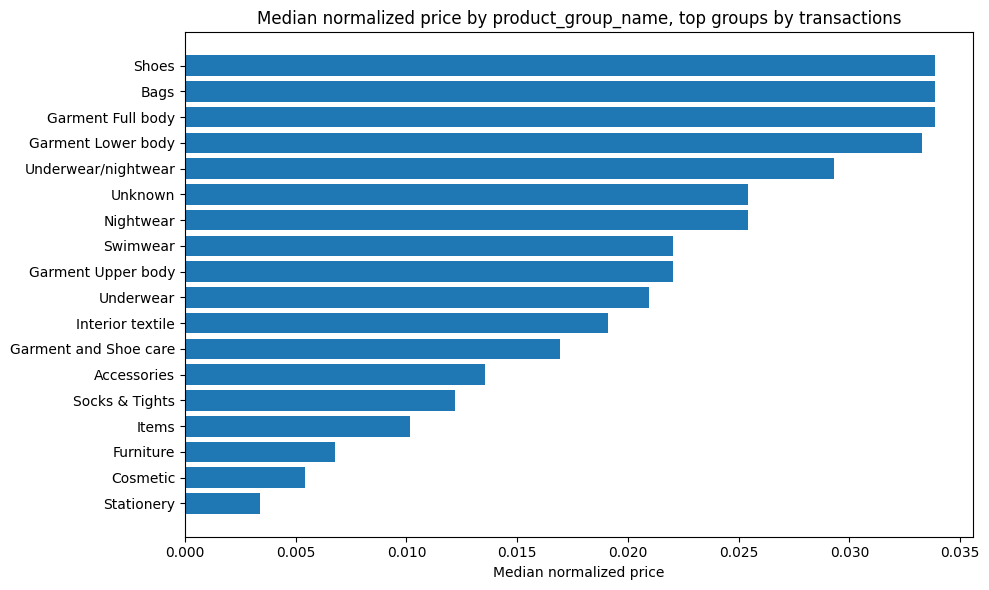

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/median_price_by_product_group_name.png


,garment_group_name,sample_transactions,avg_price,median_price,p95_price
6,Jersey Fancy,325326,0.023632,0.022017,0.050831
5,Jersey Basic,205593,0.015561,0.013542,0.033881
18,"Under-, Nightwear",186791,0.021433,0.020780,0.040661
16,Trousers,185928,0.034587,0.033881,0.059305
15,Swimwear,159598,0.022166,0.022017,0.042356
1,Blouses,158021,0.028413,0.025407,0.059305
7,Knitwear,150521,0.032204,0.030492,0.059305
3,Dresses Ladies,135158,0.036198,0.033881,0.067780
0,Accessories,103578,0.015651,0.013542,0.033881
17,Trousers Denim,80589,0.040650,0.033881,0.084729


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/sample_price_by_garment_group_name.csv


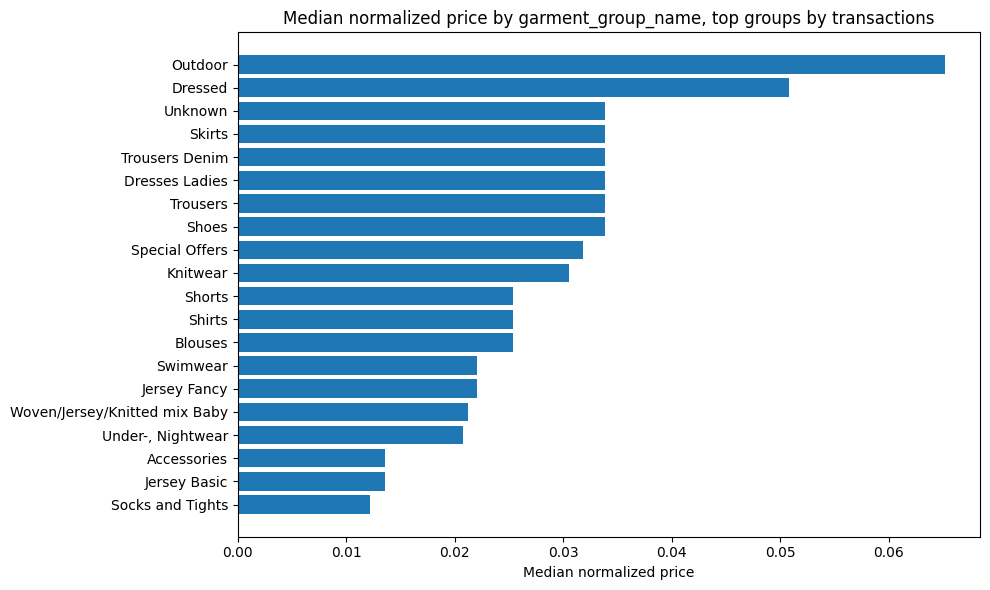

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/median_price_by_garment_group_name.png


,section_name,sample_transactions,avg_price,median_price,p95_price
44,Womens Everyday Collection,368063,0.029822,0.027102,0.054220
12,Divided Collection,237134,0.026336,0.025407,0.050831
51,"Womens Swimwear, beachwear",154362,0.022263,0.022017,0.042356
46,Womens Lingerie,138389,0.020701,0.020322,0.033881
52,Womens Tailoring,134442,0.035961,0.033881,0.067780
43,Womens Everyday Basics,97680,0.016324,0.015847,0.033881
11,Divided Basics,80572,0.014828,0.013542,0.030492
42,Womens Casual,77257,0.028734,0.025407,0.053373
27,Ladies H&M Sport,73621,0.028684,0.025407,0.050831
47,"Womens Nightwear, Socks & Tigh",69984,0.018288,0.016271,0.042356


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/sample_price_by_section_name.csv


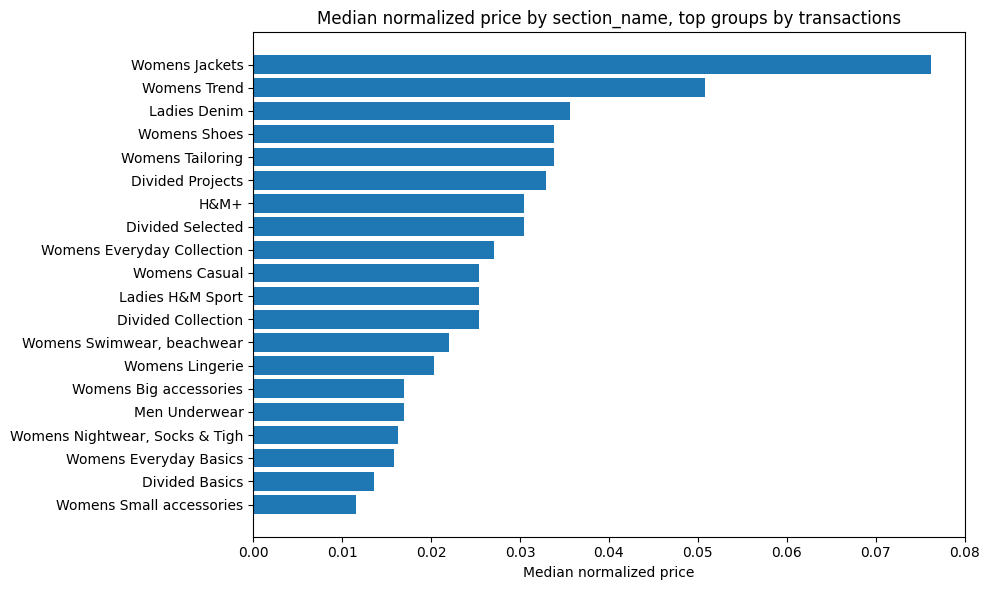

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/median_price_by_section_name.png


,index_group_name,sample_transactions,avg_price,median_price,p95_price
2,Ladieswear,1284664,0.028736,0.025407,0.067000
1,Divided,448958,0.026535,0.025407,0.057610
3,Menswear,111889,0.027509,0.024390,0.059305
4,Sport,77960,0.028743,0.025407,0.050831
0,Baby/Children,76529,0.019328,0.016932,0.042356


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/sample_price_by_index_group_name.csv


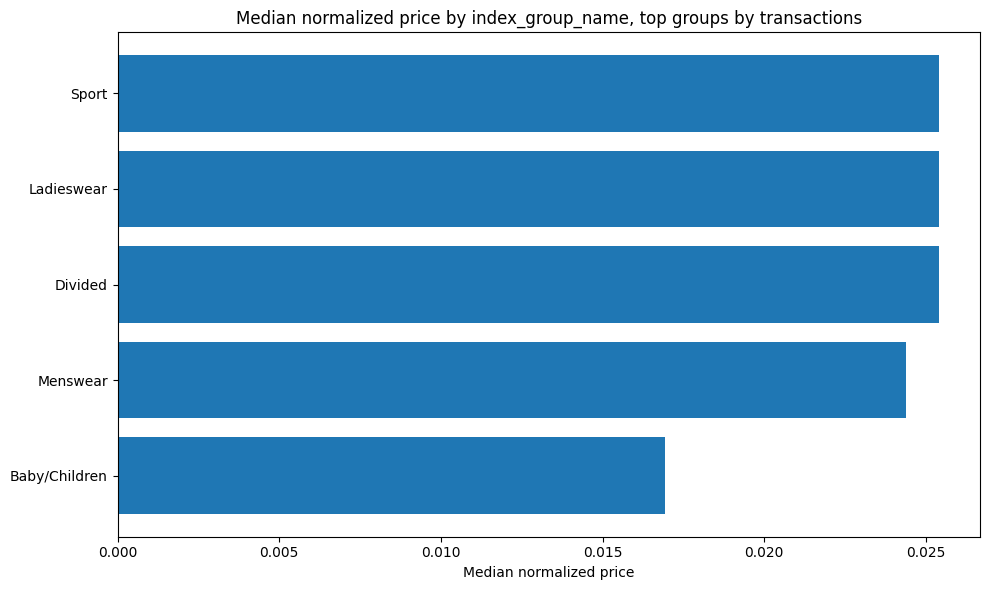

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/median_price_by_index_group_name.png


60255

In [57]:
interaction_sample_size = min(len(interactions), MAX_PLOT_SAMPLE)
interaction_sample = interactions.sample(interaction_sample_size, random_state=RANDOM_STATE)

price_join_cols = ["article_idx", "product_group_name", "garment_group_name", "section_name", "index_group_name"]
price_sample = interaction_sample[["article_idx", "price"]].merge(
    articles[[col for col in price_join_cols if col in articles.columns]],
    on="article_idx",
    how="left",
)

for col in ["product_group_name", "garment_group_name", "section_name", "index_group_name"]:
    if col not in price_sample.columns:
        continue

    price_by_col = (
        price_sample
        .groupby(col, dropna=False)
        .agg(
            sample_transactions=("price", "size"),
            avg_price=("price", "mean"),
            median_price=("price", "median"),
            p95_price=("price", lambda x: x.quantile(0.95)),
        )
        .reset_index()
        .sort_values("sample_transactions", ascending=False)
    )

    display(price_by_col.head(20))
    save_table(price_by_col, f"sample_price_by_{col}.csv")

    top_price_groups = price_by_col.head(20).sort_values("median_price", ascending=True)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_price_groups[col].astype(str), top_price_groups["median_price"])
    ax.set_title(f"Median normalized price by {col}, top groups by transactions")
    ax.set_xlabel("Median normalized price")
    ax.set_ylabel("")
    save_fig(fig, f"median_price_by_{col}.png")

# Free memory from sample join.
del interaction_sample, price_sample
gc.collect()

,product_group_name,transactions,split,percent
0,Garment Upper body,9195542,train,41.355644
1,Garment Lower body,4906851,train,22.067865
2,Garment Full body,2296460,train,10.328003
3,Underwear,1744218,train,7.844373
4,Swimwear,1567653,train,7.050297
5,Accessories,1174489,train,5.282097
6,Shoes,531217,train,2.389073
7,Socks & Tights,518516,train,2.331952
8,Nightwear,260902,train,1.173370
9,Unknown,30619,train,0.137705


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/split_drift_by_product_group_name.csv


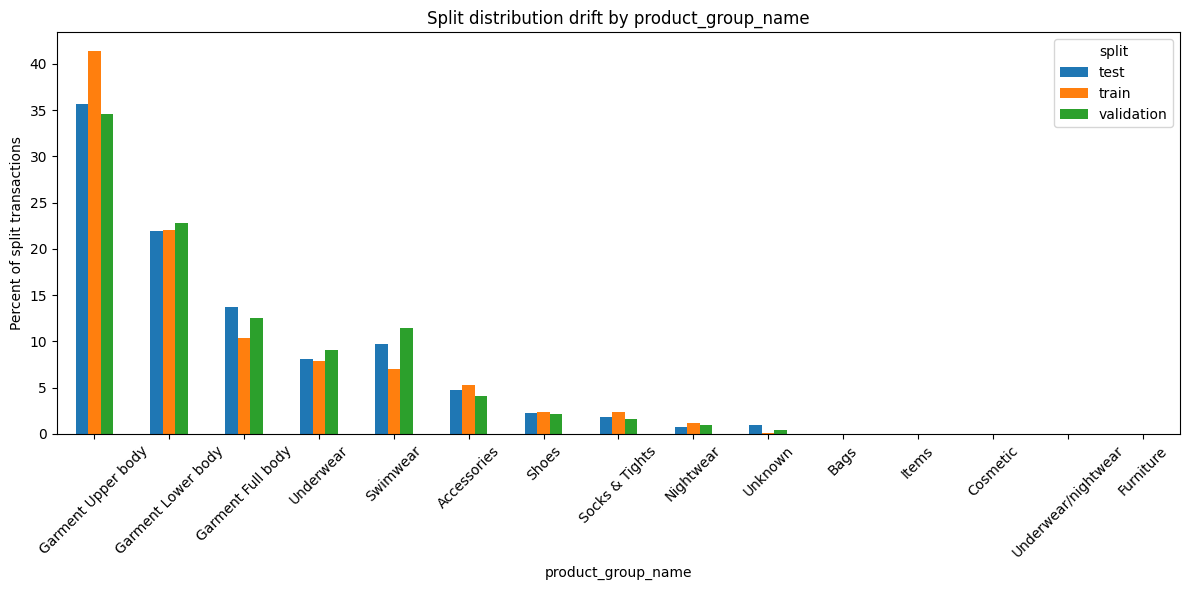

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/split_drift_by_product_group_name.png


,garment_group_name,transactions,split,percent
0,Jersey Fancy,3565614,train,16.035843
1,Jersey Basic,2159110,train,9.710291
2,Trousers,2085047,train,9.377203
3,Knitwear,2016064,train,9.066961
4,"Under-, Nightwear",2013096,train,9.053613
5,Blouses,1723953,train,7.753234
6,Swimwear,1535255,train,6.904591
7,Dresses Ladies,1446657,train,6.506134
8,Accessories,1203775,train,5.413807
9,Trousers Denim,914389,train,4.112335


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/split_drift_by_garment_group_name.csv


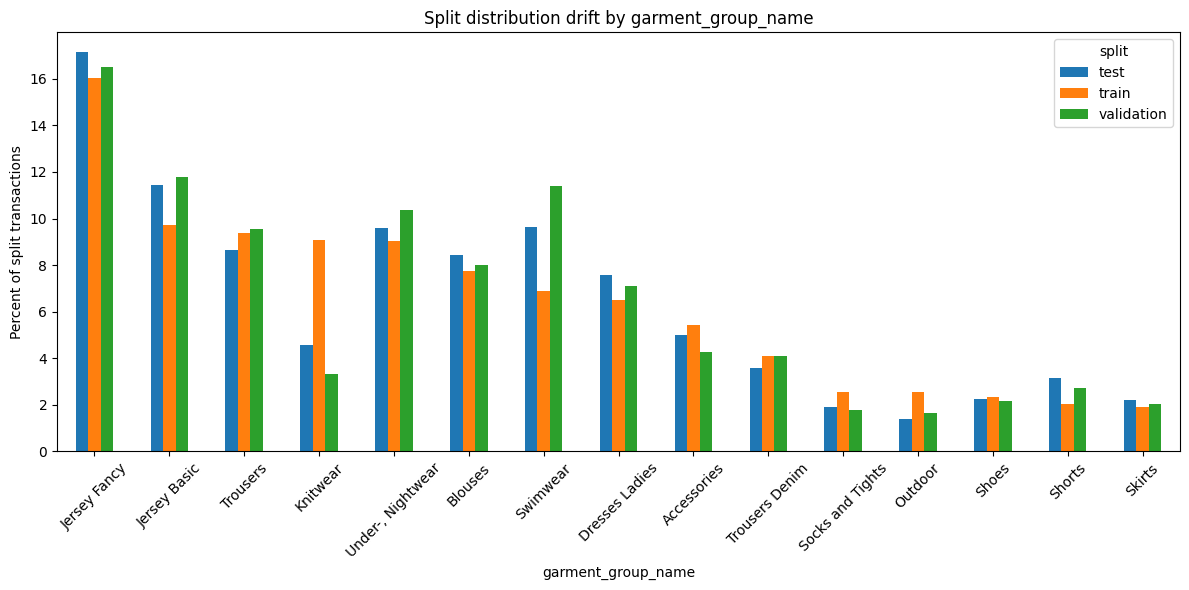

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/split_drift_by_garment_group_name.png


,index_group_name,transactions,split,percent
0,Ladieswear,14017495,train,63.041693
1,Divided,5072845,train,22.814400
2,Menswear,1253988,train,5.639633
3,Baby/Children,1047442,train,4.710722
4,Sport,843507,train,3.793553
5,Ladieswear,3203133,validation,67.279240
6,Divided,1051794,validation,22.092090
7,Menswear,234430,validation,4.924014
8,Sport,184678,validation,3.879013
9,Baby/Children,86918,validation,1.825643


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/split_drift_by_index_group_name.csv


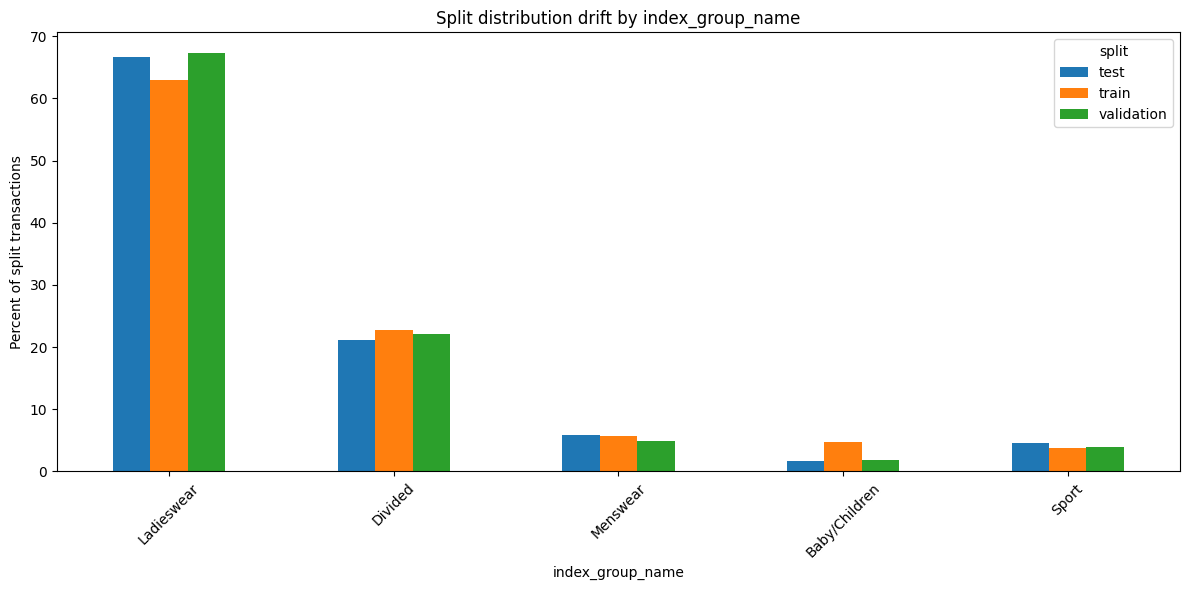

Saved plot: /kaggle/working/hm-recommender/artifacts/eda/plots/split_drift_by_index_group_name.png


In [59]:
def split_article_distribution(split_df: pd.DataFrame, split_name: str, metadata_col: str) -> pd.DataFrame:
    article_counts = split_df["article_idx"].value_counts().reset_index()
    article_counts.columns = ["article_idx", "transactions"]

    article_counts = article_counts.merge(
        articles[["article_idx", metadata_col]],
        on="article_idx",
        how="left",
    )

    result = (
        article_counts
        .groupby(metadata_col, dropna=False)["transactions"]
        .sum()
        .reset_index()
        .sort_values("transactions", ascending=False)
    )
    result["split"] = split_name
    result["percent"] = result["transactions"] / result["transactions"].sum() * 100
    return result

for metadata_col in ["product_group_name", "garment_group_name", "index_group_name"]:
    if metadata_col not in articles.columns:
        continue

    drift_table = pd.concat([
        split_article_distribution(train_interactions, "train", metadata_col),
        split_article_distribution(val_interactions, "validation", metadata_col),
        split_article_distribution(test_interactions, "test", metadata_col),
    ], ignore_index=True)

    display(drift_table.groupby("split").head(10))
    save_table(drift_table, f"split_drift_by_{metadata_col}.csv")

    pivot = drift_table.pivot_table(
        index=metadata_col,
        columns="split",
        values="percent",
        fill_value=0,
    )

    # Plot the most important groups across all splits.
    top_groups = (
        drift_table.groupby(metadata_col)["transactions"].sum().sort_values(ascending=False).head(15).index
    )
    pivot_top = pivot.loc[pivot.index.isin(top_groups)]

    fig, ax = plt.subplots(figsize=(12, 6))
    pivot_top.sort_values("train", ascending=False).plot(kind="bar", ax=ax)
    ax.set_title(f"Split distribution drift by {metadata_col}")
    ax.set_xlabel(metadata_col)
    ax.set_ylabel("Percent of split transactions")
    ax.tick_params(axis="x", rotation=45)
    save_fig(fig, f"split_drift_by_{metadata_col}.png")

In [60]:
active_customer_coverage = n_active_customers / n_customers * 100
active_article_coverage = n_active_articles / n_articles * 100

# Long-tail concentration.
total_item_purchases = item_popularity.sum()
top_100_item_share = item_popularity.sort_values(ascending=False).head(100).sum() / total_item_purchases * 100
top_1000_item_share = item_popularity.sort_values(ascending=False).head(1000).sum() / total_item_purchases * 100
top_5000_item_share = item_popularity.sort_values(ascending=False).head(5000).sum() / total_item_purchases * 100

recommender_summary = pd.DataFrame([
    {"metric": "active_customer_coverage_percent", "value": active_customer_coverage},
    {"metric": "active_article_coverage_percent", "value": active_article_coverage},
    {"metric": "observed_user_item_pair_density_percent", "value": observed_pair_density * 100},
    {"metric": "observed_user_item_pair_sparsity_percent", "value": observed_pair_sparsity * 100},
    {"metric": "mean_events_per_active_user", "value": user_activity.mean()},
    {"metric": "median_events_per_active_user", "value": user_activity.median()},
    {"metric": "mean_events_per_active_article", "value": item_popularity.mean()},
    {"metric": "median_events_per_active_article", "value": item_popularity.median()},
    {"metric": "top_100_items_purchase_share_percent", "value": top_100_item_share},
    {"metric": "top_1000_items_purchase_share_percent", "value": top_1000_item_share},
    {"metric": "top_5000_items_purchase_share_percent", "value": top_5000_item_share},
])

display(recommender_summary)
save_table(recommender_summary, "recommender_specific_summary.csv")

eda_summary["recommender_summary"] = recommender_summary.to_dict(orient="records")
save_json(eda_summary, "eda_summary.json")

,metric,value
0,active_customer_coverage_percent,99.293065
1,active_article_coverage_percent,99.057247
2,observed_user_item_pair_density_percent,0.018858
3,observed_user_item_pair_sparsity_percent,99.981142
4,mean_events_per_active_user,23.334631
5,median_events_per_active_user,9.000000
6,mean_events_per_active_article,304.057735
7,median_events_per_active_article,65.000000
8,top_100_items_purchase_share_percent,4.600906
9,top_1000_items_purchase_share_percent,18.159831


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/recommender_specific_summary.csv
Saved JSON: /kaggle/working/hm-recommender/artifacts/eda/eda_summary.json


## Extra recommender-readiness checks

These cells add two checks that are useful before ALS and similarity modeling: metadata completeness for content-based similarity and a sampled co-purchase feasibility table.

In [61]:
# Metadata sparsity / completeness check for content-based similarity.
content_similarity_columns = [
    "prod_name",
    "product_type_name",
    "product_group_name",
    "graphical_appearance_name",
    "colour_group_name",
    "department_name",
    "index_name",
    "section_name",
    "garment_group_name",
    "detail_desc",
]

available_content_columns = [col for col in content_similarity_columns if col in articles.columns]

metadata_similarity_readiness = []
for col in available_content_columns:
    missing_count = int(articles[col].isna().sum())
    missing_percent = float(missing_count / len(articles) * 100)
    unique_values = int(articles[col].nunique(dropna=True))
    metadata_similarity_readiness.append(
        {
            "column": col,
            "missing_count": missing_count,
            "missing_percent": round(missing_percent, 4),
            "unique_values": unique_values,
        }
    )

metadata_similarity_readiness = pd.DataFrame(metadata_similarity_readiness)
display(metadata_similarity_readiness)
save_table(metadata_similarity_readiness, "metadata_similarity_readiness.csv")

eda_summary["metadata_similarity_readiness"] = metadata_similarity_readiness.to_dict(orient="records")
save_json(eda_summary, "eda_summary.json")

,column,missing_count,missing_percent,unique_values
0,prod_name,0,0.000000,45875
1,product_type_name,0,0.000000,131
2,product_group_name,0,0.000000,19
3,graphical_appearance_name,0,0.000000,30
4,colour_group_name,0,0.000000,50
5,department_name,0,0.000000,250
6,index_name,0,0.000000,10
7,section_name,0,0.000000,56
8,garment_group_name,0,0.000000,21
9,detail_desc,0,0.000000,43405


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/metadata_similarity_readiness.csv
Saved JSON: /kaggle/working/hm-recommender/artifacts/eda/eda_summary.json


In [62]:
# Sampled co-purchase feasibility analysis.
# Full pair generation can be very large, so this uses active users and a capped user sample.
MAX_COPURCHASE_USERS = 50_000
MAX_ITEMS_PER_USER_FOR_PAIRS = 30
TOP_COPURCHASE_PAIRS = 200

active_user_items = (
    interactions
    .groupby("customer_idx")["article_idx"]
    .agg(lambda values: sorted(set(values.to_numpy(dtype=np.int32))))
)

active_user_items = active_user_items[active_user_items.apply(len) >= 2]

if len(active_user_items) > MAX_COPURCHASE_USERS:
    active_user_items = active_user_items.sample(MAX_COPURCHASE_USERS, random_state=RANDOM_STATE)

from collections import Counter
from itertools import combinations

pair_counter = Counter()

for items in active_user_items:
    if len(items) > MAX_ITEMS_PER_USER_FOR_PAIRS:
        items = items[:MAX_ITEMS_PER_USER_FOR_PAIRS]
    for a, b in combinations(items, 2):
        pair_counter[(int(a), int(b))] += 1

copurchase_pairs = pd.DataFrame(
    [
        {"article_idx_a": a, "article_idx_b": b, "co_purchase_users": count}
        for (a, b), count in pair_counter.most_common(TOP_COPURCHASE_PAIRS)
    ]
)

if len(copurchase_pairs) > 0:
    article_names = articles[[col for col in ["article_idx", "article_id", "prod_name", "product_type_name", "garment_group_name"] if col in articles.columns]].copy()
    copurchase_pairs = copurchase_pairs.merge(
        article_names.add_suffix("_a"),
        left_on="article_idx_a",
        right_on="article_idx_a",
        how="left",
    )
    copurchase_pairs = copurchase_pairs.merge(
        article_names.add_suffix("_b"),
        left_on="article_idx_b",
        right_on="article_idx_b",
        how="left",
    )

display(copurchase_pairs.head(30))
save_table(copurchase_pairs, "sampled_top_copurchase_pairs.csv")

eda_summary["copurchase_feasibility"] = {
    "sampled_users": int(len(active_user_items)),
    "max_items_per_user_for_pairs": int(MAX_ITEMS_PER_USER_FOR_PAIRS),
    "unique_pairs_found": int(len(pair_counter)),
    "saved_top_pairs": int(len(copurchase_pairs)),
}
save_json(eda_summary, "eda_summary.json")

,article_idx_a,article_idx_b,co_purchase_users,article_id_a,prod_name_a,product_type_name_a,garment_group_name_a,article_id_b,prod_name_b,product_type_name_b,garment_group_name_b
0,45795,47298,246,0684209013,Simple as That Triangle Top,Bikini top,Swimwear,0688537011,Simple as that Cheeky Tanga,Swimwear bottom,Swimwear
1,53892,53893,226,0706016001,Jade HW Skinny Denim TRS,Trousers,Trousers,0706016002,Jade HW Skinny Denim TRS,Trousers,Trousers
2,24836,24837,210,0610776001,Tilly (1),T-shirt,Jersey Basic,0610776002,Tilly (1),T-shirt,Jersey Basic
3,1713,1714,199,0372860001,7p Basic Shaftless,Socks,Socks and Tights,0372860002,7p Basic Shaftless,Socks,Socks and Tights
4,74,75,147,0160442007,3p Sneaker Socks,Socks,Socks and Tights,0160442010,3p Sneaker Socks,Socks,Socks and Tights
5,45791,47295,140,0684209004,Simple as That Triangle Top,Bikini top,Swimwear,0688537004,Simple as that Cheeky Tanga,Swimwear bottom,Swimwear
6,13740,22656,139,0559630026,Timeless Triangle Top,Bikini top,Swimwear,0599580055,Timeless Midrise Brief,Swimwear bottom,Swimwear
7,17043,17044,134,0572797001,ESSENTIAL TANKTOP LACE TVP,Vest top,Jersey Fancy,0572797002,ESSENTIAL TANKTOP LACE TVP,Vest top,Jersey Fancy
8,45802,47303,131,0684209027,Simple as That Triangle Top,Bikini top,Swimwear,0688537021,Simple as that Cheeky Tanga,Swimwear bottom,Swimwear
9,53892,53894,128,0706016001,Jade HW Skinny Denim TRS,Trousers,Trousers,0706016003,Jade HW Skinny Denim TRS,Trousers,Trousers


Saved table: /kaggle/working/hm-recommender/artifacts/eda/tables/sampled_top_copurchase_pairs.csv
Saved JSON: /kaggle/working/hm-recommender/artifacts/eda/eda_summary.json


In [63]:
print("EDA completed successfully.")
print()
print("Key outputs saved in:")
print("EDA tables:", TABLES_DIR)
print("EDA plots:", PLOTS_DIR)
print("EDA summary:", EDA_DIR / "eda_summary.json")
print()
print("Next notebook: 03_popularity_baseline.ipynb")

EDA completed successfully.

Key outputs saved in:
EDA tables: /kaggle/working/hm-recommender/artifacts/eda/tables
EDA plots: /kaggle/working/hm-recommender/artifacts/eda/plots
EDA summary: /kaggle/working/hm-recommender/artifacts/eda/eda_summary.json

Next notebook: 03_popularity_baseline.ipynb
